In [3]:
import pandas as pd
import re
import struct
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import matplotlib.colors as mcolors

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


In [4]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


In [5]:
# colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']
# Wong (2011) colorblind-safe palette – 8 distinct colors
# Works for deuteranopia, protanopia, and tritanopia

cute_colors = ['royalblue', 'crimson', 'green', 'darkorange', 'brown', 'blue', 'coral', 'indigo', 'magenta', 'black']

# Grayscale palette – 10 shades from near-black to light gray
# Paired with distinct markers and line styles for full grayscale legibility
GS_COLORS = [
    '#000000',  # Black
    '#1a1a1a',  # Near black
    '#333333',  # Very dark gray
    '#4d4d4d',  # Dark gray
    '#666666',  # Medium dark gray
    '#808080',  # Medium gray
    '#999999',  # Medium light gray
    '#b3b3b3',  # Light gray
    '#cccccc',  # Very light gray
    '#e6e6e6',  # Near white (use only on dark backgrounds)
]

CB_COLORS = [
    '#000000',  # Black
    '#E69F00',  # Orange
    '#56B4E9',  # Sky blue
    '#009E73',  # Bluish green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish purple
    '#994F00',  # Brown        
    '#006CD1',  # Cerulean     
]

# Red-family palette – 10 perceptually distinct red-adjacent colors
# Ranges from deep maroon to coral/salmon, with warm and cool reds
RED_COLORS = [
    '#8B0000',  # Dark red / maroon
    '#CC0000',  # Pure strong red
    '#FF4500',  # Orange-red (OrangeRed)
    '#DC143C',  # Crimson (blue-toned red)
    '#B22222',  # Firebrick
    '#FF6347',  # Tomato (warm coral-red)
    '#C71585',  # Medium violet-red (pinkish)
    '#A0001C',  # Deep rose-red
    '#FF0066',  # Hot red-pink
    '#7B1010',  # Deep brick red
]

colors = cute_colors

# Distinct markers and line styles for extra redundancy (grayscale-safe)
CB_MARKERS    = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
CB_LINESTYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']


##  Data reading

In [6]:
# gas = 'Ar'
gas = 'Xe'

pressure     = 8.5


In [7]:
if gas == 'Ar':
    runs    = {8.5:f'Run{172}SPheCH' 
               ,7.5:f'Run{00}SPheCH'
               ,6.5:f'Run{00}SPheCH'
               ,5.5:f'Run{00}SPheCH'
               ,4.5:f'Run{00}SPheCH'
               ,3.5:f'Run{00}SPheCH'
               ,2.5:f'Run{00}SPheCH'
               ,1.5:f'Run{00}SPheCH'
               }
    
    temperatures = {8.5:f'{6}deg'
                    ,7.5:f'{7}deg'
                    ,6.5:f'{8}deg'
                    ,5.5:f'{9}deg'
                    ,4.5:f'{10}deg'
                    ,3.5:f'{11}deg'
                    ,2.5:f'{12}deg'
                    ,1.5:f'{13.5}deg'
                    }        

if gas == 'Xe':
    runs    = {#8.5:f'Run{00}SPheCH' 
               8.5:f'Run{65}SPheCH'
               ,7.5:f'Run{00}SPheCH'
               ,6.5:f'Run{00}SPheCH'
               ,5.5:f'Run{00}SPheCH'
               ,4.5:f'Run{00}SPheCH'
               ,3.5:f'Run{00}SPheCH'
               ,2.5:f'Run{00}SPheCH'
               ,1.5:f'Run{115}SPheCH'
               }
    
    temperatures = {#8.5:f'{8}deg'
                    8.5:f'{18}deg'
                    ,7.5:f'{10}deg'
                    ,6.5:f'{12}deg'
                    ,5.5:f'{13}deg'
                    ,4.5:f'{11.5}deg'
                    ,3.5:f'{13}v2deg'
                    ,2.5:f'{13}v3deg'
                    ,1.5:f'{14}deg'
                    }        


In [8]:
base        = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data"
# run_base        = runs[pressure]    
# temperature     = temperatures[pressure]
run_base        = f'Run{65}SPheCH'  
temperature     = f'{18}deg'

print(f'Using {run_base}s for {gas} @ {pressure}bars + {temperature}')

Using Run65SPheCHs for Xe @ 8.5bars + 18deg


In [9]:
# --- All 4 channels are processed together ---
all_channels = ['CH1', 'CH2', 'CH3', 'CH4']

nchannels       = 1 # per file
nevents_per_wvf = 2000

samples_per_waveform = 124
# samples_per_waveform = 752

event_header_bytes = 28
# event_header_bytes = 3036

# sample_binning = 1
sample_binning = 8e-9

nfiles = None
start  = 1


In [10]:
# Read data for all 4 channels and merge into a single DataFrame
# Each channel lives in its own run directory (Run172SPheCH1, ..., Run172SPheCH4).
# parse_data returns a column named 'CH1'; we rename it to the correct channel name.

channel_dfs = {}

for ch_idx, ch in enumerate(all_channels):
    channel_num = ch_idx + 1
    run         = f'{run_base}{channel_num}'
    run_dir     = f'{base}/{run}'

    dataframes = []
    for i, file in enumerate(tqdm(os.listdir(run_dir)[start:nfiles],
                                   desc=f'Reading {ch} .bin files', unit='file')):
        if file.endswith('.bin'):
            file_path = os.path.join(run_dir, file)
            df_tmp = parse_data.parse_wf_from_binary(
                file_path,
                channels=nchannels,
                n_events=nevents_per_wvf,
                file_idx=i,
                event_header_bytes=event_header_bytes
            )
            dataframes.append(df_tmp)

    ch_df = pd.concat(dataframes, ignore_index=True)
    ch_df.rename(columns={'CH1': ch}, inplace=True)   # parse_data always returns 'CH1'
    channel_dfs[ch] = ch_df

# Merge all channels on event + TIME (they share the same event structure)
df = channel_dfs['CH1'][['event', 'TIME', 'CH1']].copy()
for ch in ['CH2', 'CH3', 'CH4']:
    df = df.merge(channel_dfs[ch][['event', 'TIME', ch]], on=['event', 'TIME'], how='inner')

print(f'Merged DataFrame shape: {df.shape}')
df.tail()


Reading CH4 .bin files: 100%|██████████| 29/29 [00:16<00:00,  1.80file/s]


Merged DataFrame shape: (7192000, 6)


,event,TIME,CH1,CH2,CH3,CH4
7191995,57999,9.600000e-07,-1061.796265,-539.705383,-627.405945,-369.415588
7191996,57999,9.680000e-07,-1065.467163,-544.246887,-620.168274,-320.754852
7191997,57999,9.760000e-07,-1069.260376,-548.051941,-613.789368,-279.660828
7191998,57999,9.840000e-07,-1074.215942,-551.550171,-615.445435,-247.917542
7191999,57999,9.920000e-07,-1079.110474,-560.203613,-619.922974,-229.339111


##  Data selection

In [29]:
event_list = df['event'].unique()
nevents    = len(event_list)
print(f'Total nevents = {nevents}')


Total nevents = 58000


###  Baseline

Same method as `ChargeSpectrum.ipynb`'s baseline-correction step (histogram the pretrigger samples, locate the peak with mode + local quadratic-in-log fit), computed from this run instead of the hardcoded values previously here. Everything below that reads `fixBaselines_Amp` (the CHARGE-vs-TIME plot, waveform density, both Finger Plots) picks this up automatically - check the fitted red curve visually tracks the histogram peak per channel.

In [32]:
def compute_baselines(df, nevents, pretrigger, run_base=None, plot=True):
    """
    Per-channel baseline offset from the pretrigger samples - same method
    as ChargeSpectrum.ipynb's "Baseline correction" step: histogram the
    first `pretrigger` samples of every waveform (no real signal should
    have arrived yet), then locate the peak by fitting a quadratic to
    log(counts + 1) in a small window around the tallest bin (equivalent
    to a local Gaussian fit, since the log of a Gaussian is a parabola,
    but more robust to noisy bins in the wings than fitting the raw counts
    directly). Falls back to the raw histogram mode if that fit fails.

    Before histogramming, drops samples pinned exactly at the pretrigger
    min/max - some channels (e.g. CH3 in Run65) saturate the digitizer's
    rail on a few percent of samples, and that narrow spike is tall enough
    in a fine-binned histogram to outweigh the real (broader) baseline
    peak, fooling argmax into picking the rail instead of the true
    pretrigger noise peak.

    The peak position peak_value = -b/(2a) is a nonlinear function of the
    quadratic fit's own parameters (a, b), so its uncertainty is obtained
    by propagating the fit's parameter covariance (from np.polyfit's
    cov=True) through that formula, not just quoting the fit's residuals -
    var(peak) = (d peak/da)^2 var(a) + (d peak/db)^2 var(b)
                + 2 (d peak/da)(d peak/db) cov(a,b).

    Returns two {'CH1': ..., 'CH2': ..., 'CH3': ..., 'CH4': ...} dicts in
    the same format as the old hardcoded fixBaselines_Amp - assign the
    first back to that name to use it, since every cell below reads that
    global by name.

    Returns
    -------
    fixBaselines_Amp, fixBaselines_Amp_err : dict of {channel: float}
        Baseline [mV] and its fit uncertainty [mV], per channel. The
        uncertainty is NaN for a channel that fell back to the raw
        histogram mode (no fit to propagate an error from).
    """
    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
        title = f'Baseline (pretrigger={pretrigger})'
        if run_base:
            title += f' — {run_base}s'
        fig.suptitle(title)
        axs_flat = axs.flatten()

    fixBaselines_Amp, fixBaselines_Amp_err = {}, {}
    for i, channel in enumerate([1, 2, 3, 4]):
        ch = f'CH{channel}'

        voltage   = df[ch].values
        v_matrix  = voltage.reshape(nevents, -1)
        baselines = v_matrix[:, :pretrigger].flatten()

        clipped = (baselines == baselines.min()) | (baselines == baselines.max())
        if clipped.mean() > 0.001:
            print(f'{ch}: dropping {clipped.mean()*100:.1f}% of pretrigger samples pinned at the ADC rail')
            baselines = baselines[~clipped]

        counts, bins = np.histogram(baselines, bins=int(0.5 * np.sqrt(len(baselines))),
                                     range=(baselines.min(), 1000))
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])
        mode_initial = bin_centers[np.argmax(counts)]

        bin_width = bins[1] - bins[0]
        window    = 0.05 * len(bins) * bin_width
        fit_mask  = (bin_centers >= mode_initial - window) & (bin_centers <= mode_initial + window)
        x_fit = bin_centers[fit_mask]
        y_fit = np.log(counts[fit_mask] + 1)

        coeffs = None
        try:
            coeffs, cov = np.polyfit(x_fit, y_fit, 2, cov=True)
            a, b, _ = coeffs
            if a >= 0:
                raise ValueError('quadratic fit is not concave down (no real peak in the fit window)')
            peak_value = -b / (2 * a)

            # error propagation through peak_value = -b/(2a)
            dpeak_da = b / (2 * a**2)
            dpeak_db = -1 / (2 * a)
            peak_var = (dpeak_da**2 * cov[0, 0] + dpeak_db**2 * cov[1, 1]
                        + 2 * dpeak_da * dpeak_db * cov[0, 1])
            peak_err = np.sqrt(max(peak_var, 0))
        except Exception as e:
            print(f'Baseline fit failed for {ch} ({e}), using histogram mode instead')
            coeffs = None
            peak_value = mode_initial
            peak_err   = np.nan

        fixBaselines_Amp[ch]     = peak_value
        fixBaselines_Amp_err[ch] = peak_err

        if plot:
            ax = axs_flat[i]
            ax.hist(baselines, bins=bins, color=colors[i], alpha=0.3, label=ch)
            if coeffs is not None:
                x_fine = np.linspace(x_fit.min(), x_fit.max(), 200)
                ax.plot(x_fine, np.exp(np.polyval(coeffs, x_fine)) - 1, '-', color=colors[i], lw=2, label='Quadratic fit')
            ax.axvline(peak_value, color='black', linestyle='--', lw=2,
                       label=f'{peak_value:.1f} ± {peak_err:.1f} mV')
            ax.set_xlabel('Baseline [mV]')
            ax.set_ylabel('Counts')
            ax.set_yscale('log')
            ax.grid(True)
            ax.legend(fontsize=font_size * 0.7)

    if plot:
        plt.tight_layout()
        plt.show()

    return fixBaselines_Amp, fixBaselines_Amp_err

CH1: dropping 0.9% of pretrigger samples pinned at the ADC rail
CH2: dropping 2.0% of pretrigger samples pinned at the ADC rail
CH3: dropping 2.5% of pretrigger samples pinned at the ADC rail
CH4: dropping 0.7% of pretrigger samples pinned at the ADC rail


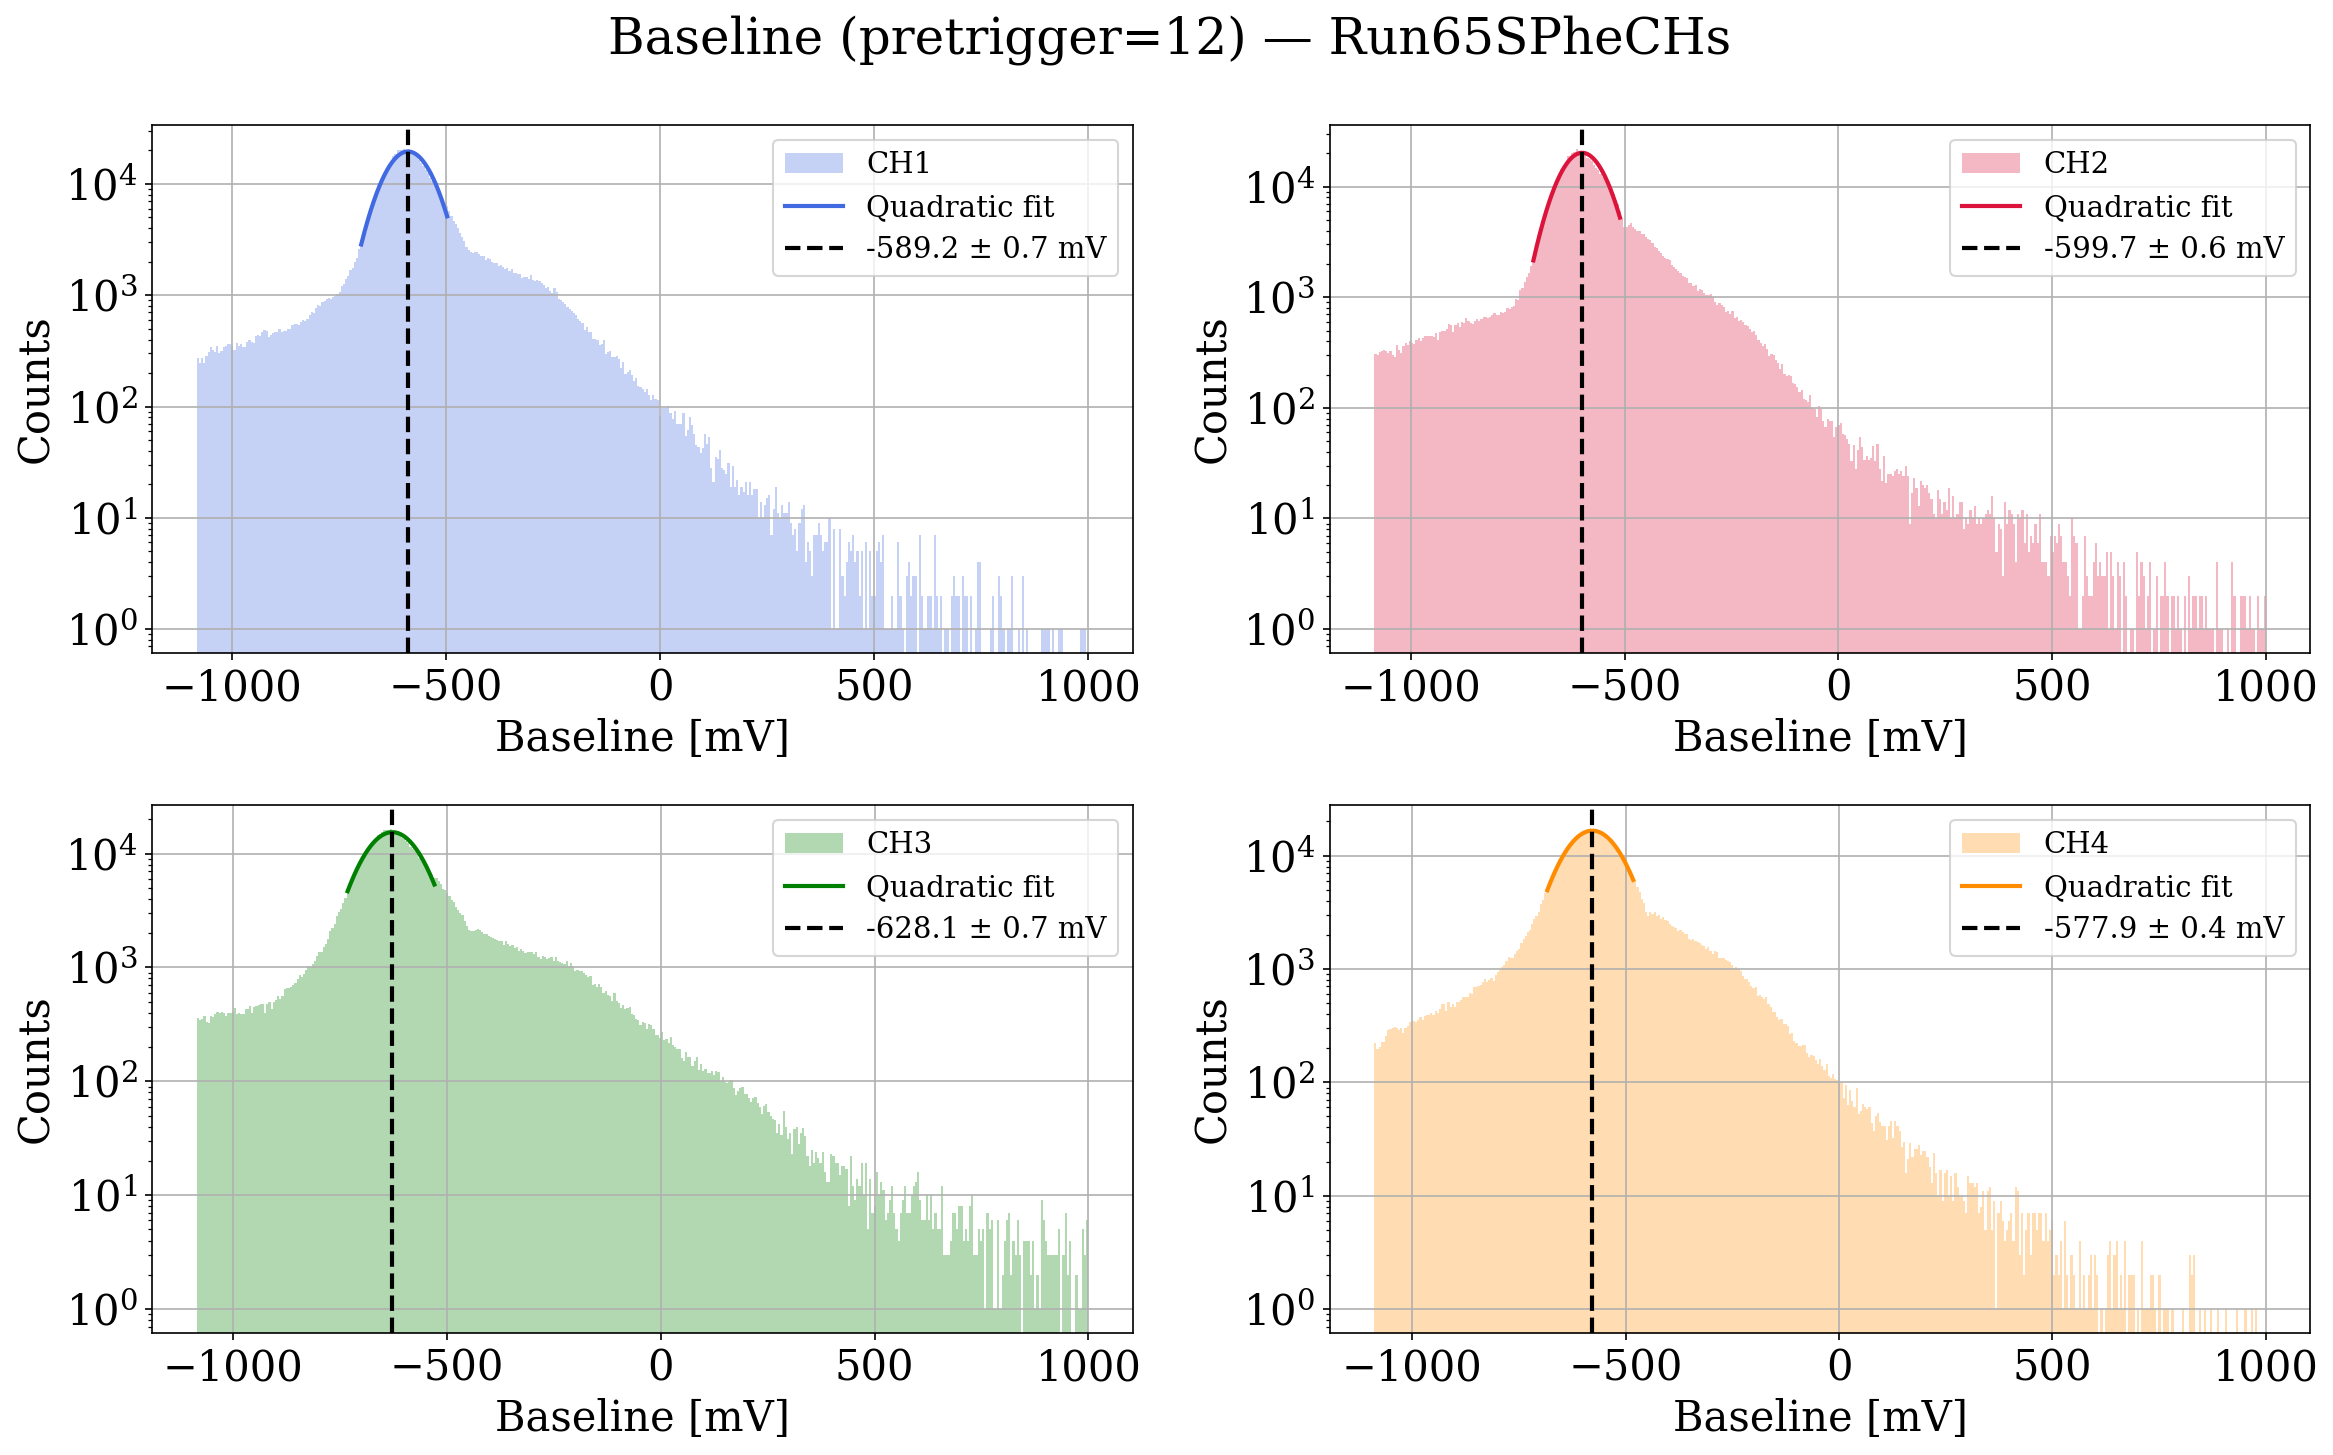

fixBaselines_Amp: {'CH1': np.float64(-589.228357957149), 'CH2': np.float64(-599.6683659743088), 'CH3': np.float64(-628.0959169802776), 'CH4': np.float64(-577.8710095147569)}
fixBaselines_Amp_err: {'CH1': np.float64(0.6653241249769055), 'CH2': np.float64(0.641485731787257), 'CH3': np.float64(0.7006441936052794), 'CH4': np.float64(0.41073567349182594)}


In [33]:
pretrigger = 12   # pretrigger samples used as the baseline region - waveform is only 124 samples long

fixBaselines_Amp, fixBaselines_Amp_err = compute_baselines(df, nevents, pretrigger, run_base)
print('fixBaselines_Amp:', fixBaselines_Amp)
print('fixBaselines_Amp_err:', fixBaselines_Amp_err)

In [14]:
channels = all_channels   # ['CH1', 'CH2', 'CH3', 'CH4']

selected_event = 202


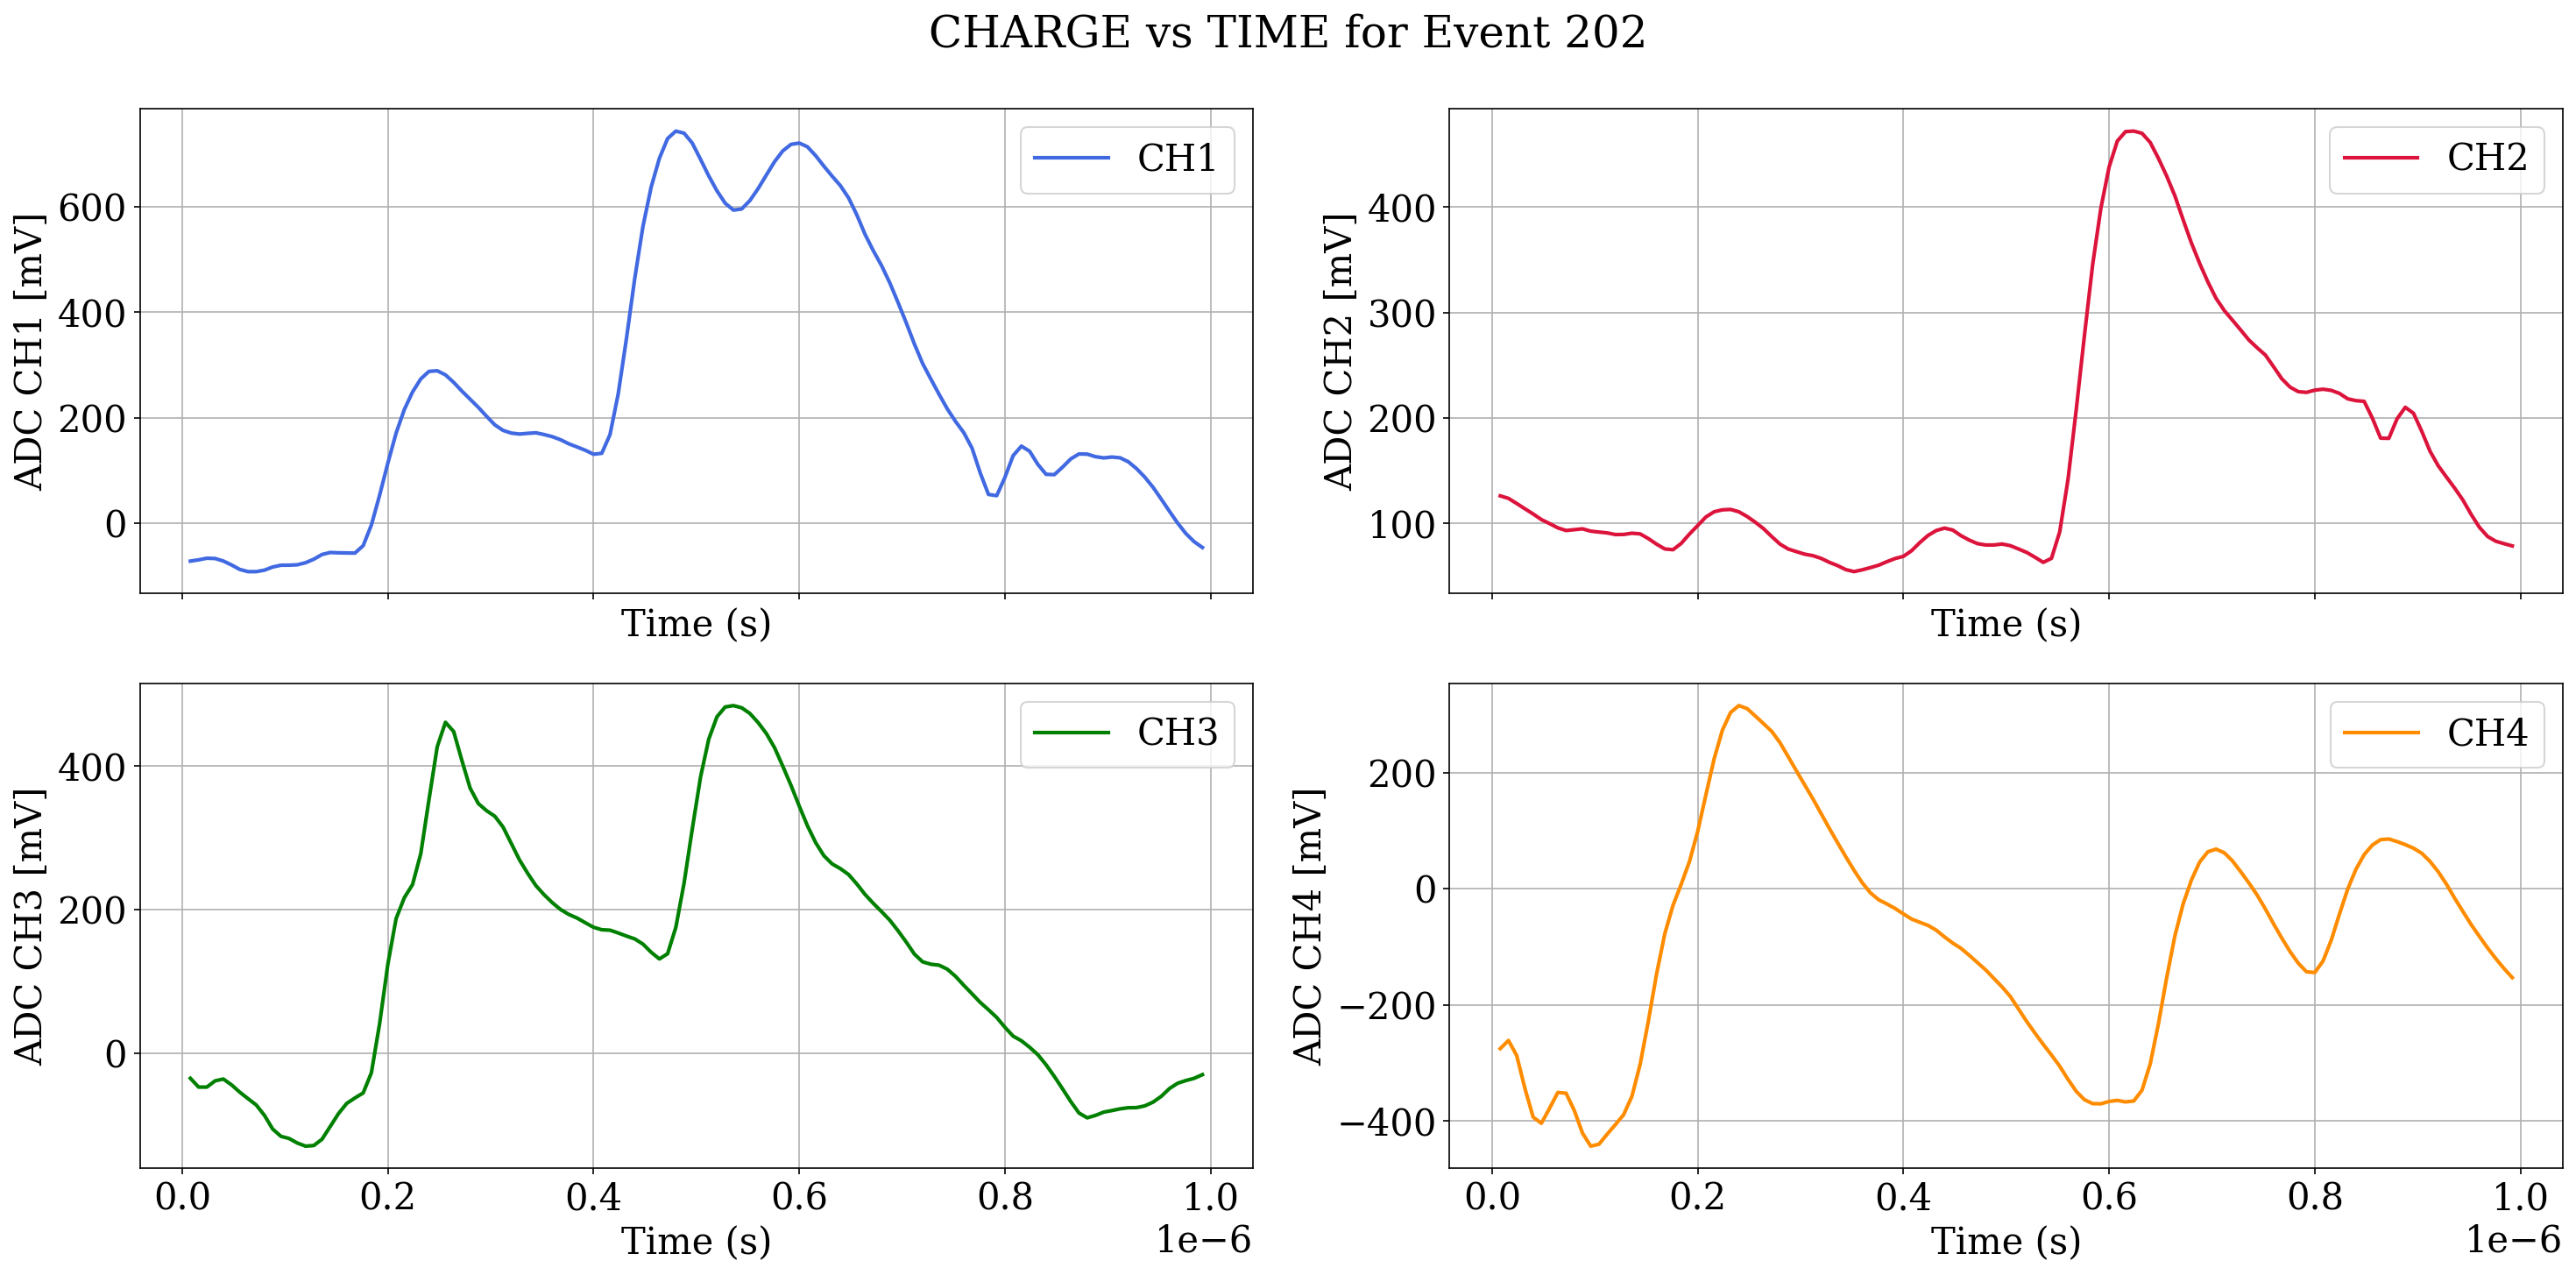

In [15]:
df_event = df[df['event'] == event_list[selected_event]]


fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'CHARGE vs TIME for Event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    df_event_corrected = df_event - fixBaselines_Amp[ch]
    ax.plot(df_event['TIME'].values, df_event_corrected[ch].values,
            marker='', linestyle='-', color=colors[i], markersize=3, linewidth=2, label=ch)
    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


##  Data filtering

In [16]:
# Remove events with more than 4 peaks above threshold across all channels
def count_high_peaks(group, threshold=2000):
    peak_count = 0
    for ch in channels:
        peaks, _ = find_peaks(group[ch].values, height=threshold)
        peak_count += len(peaks)
    return peak_count

peak_counts  = df.groupby('event').apply(count_high_peaks)
valid_events = peak_counts[peak_counts <= 4].index

filtered_df = df[df['event'].isin(valid_events)]

event_list = filtered_df['event'].unique()
nevents    = len(event_list)
print(f'Events after filtering: {nevents}')


/tmp/ipykernel_16582/3951954891.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_counts  = df.groupby('event').apply(count_high_peaks)


Events after filtering: 57998


##  Integration window

In [17]:
window_width = 20

t_matrix = filtered_df['TIME'].values.reshape(nevents, -1)
time     = t_matrix[0]


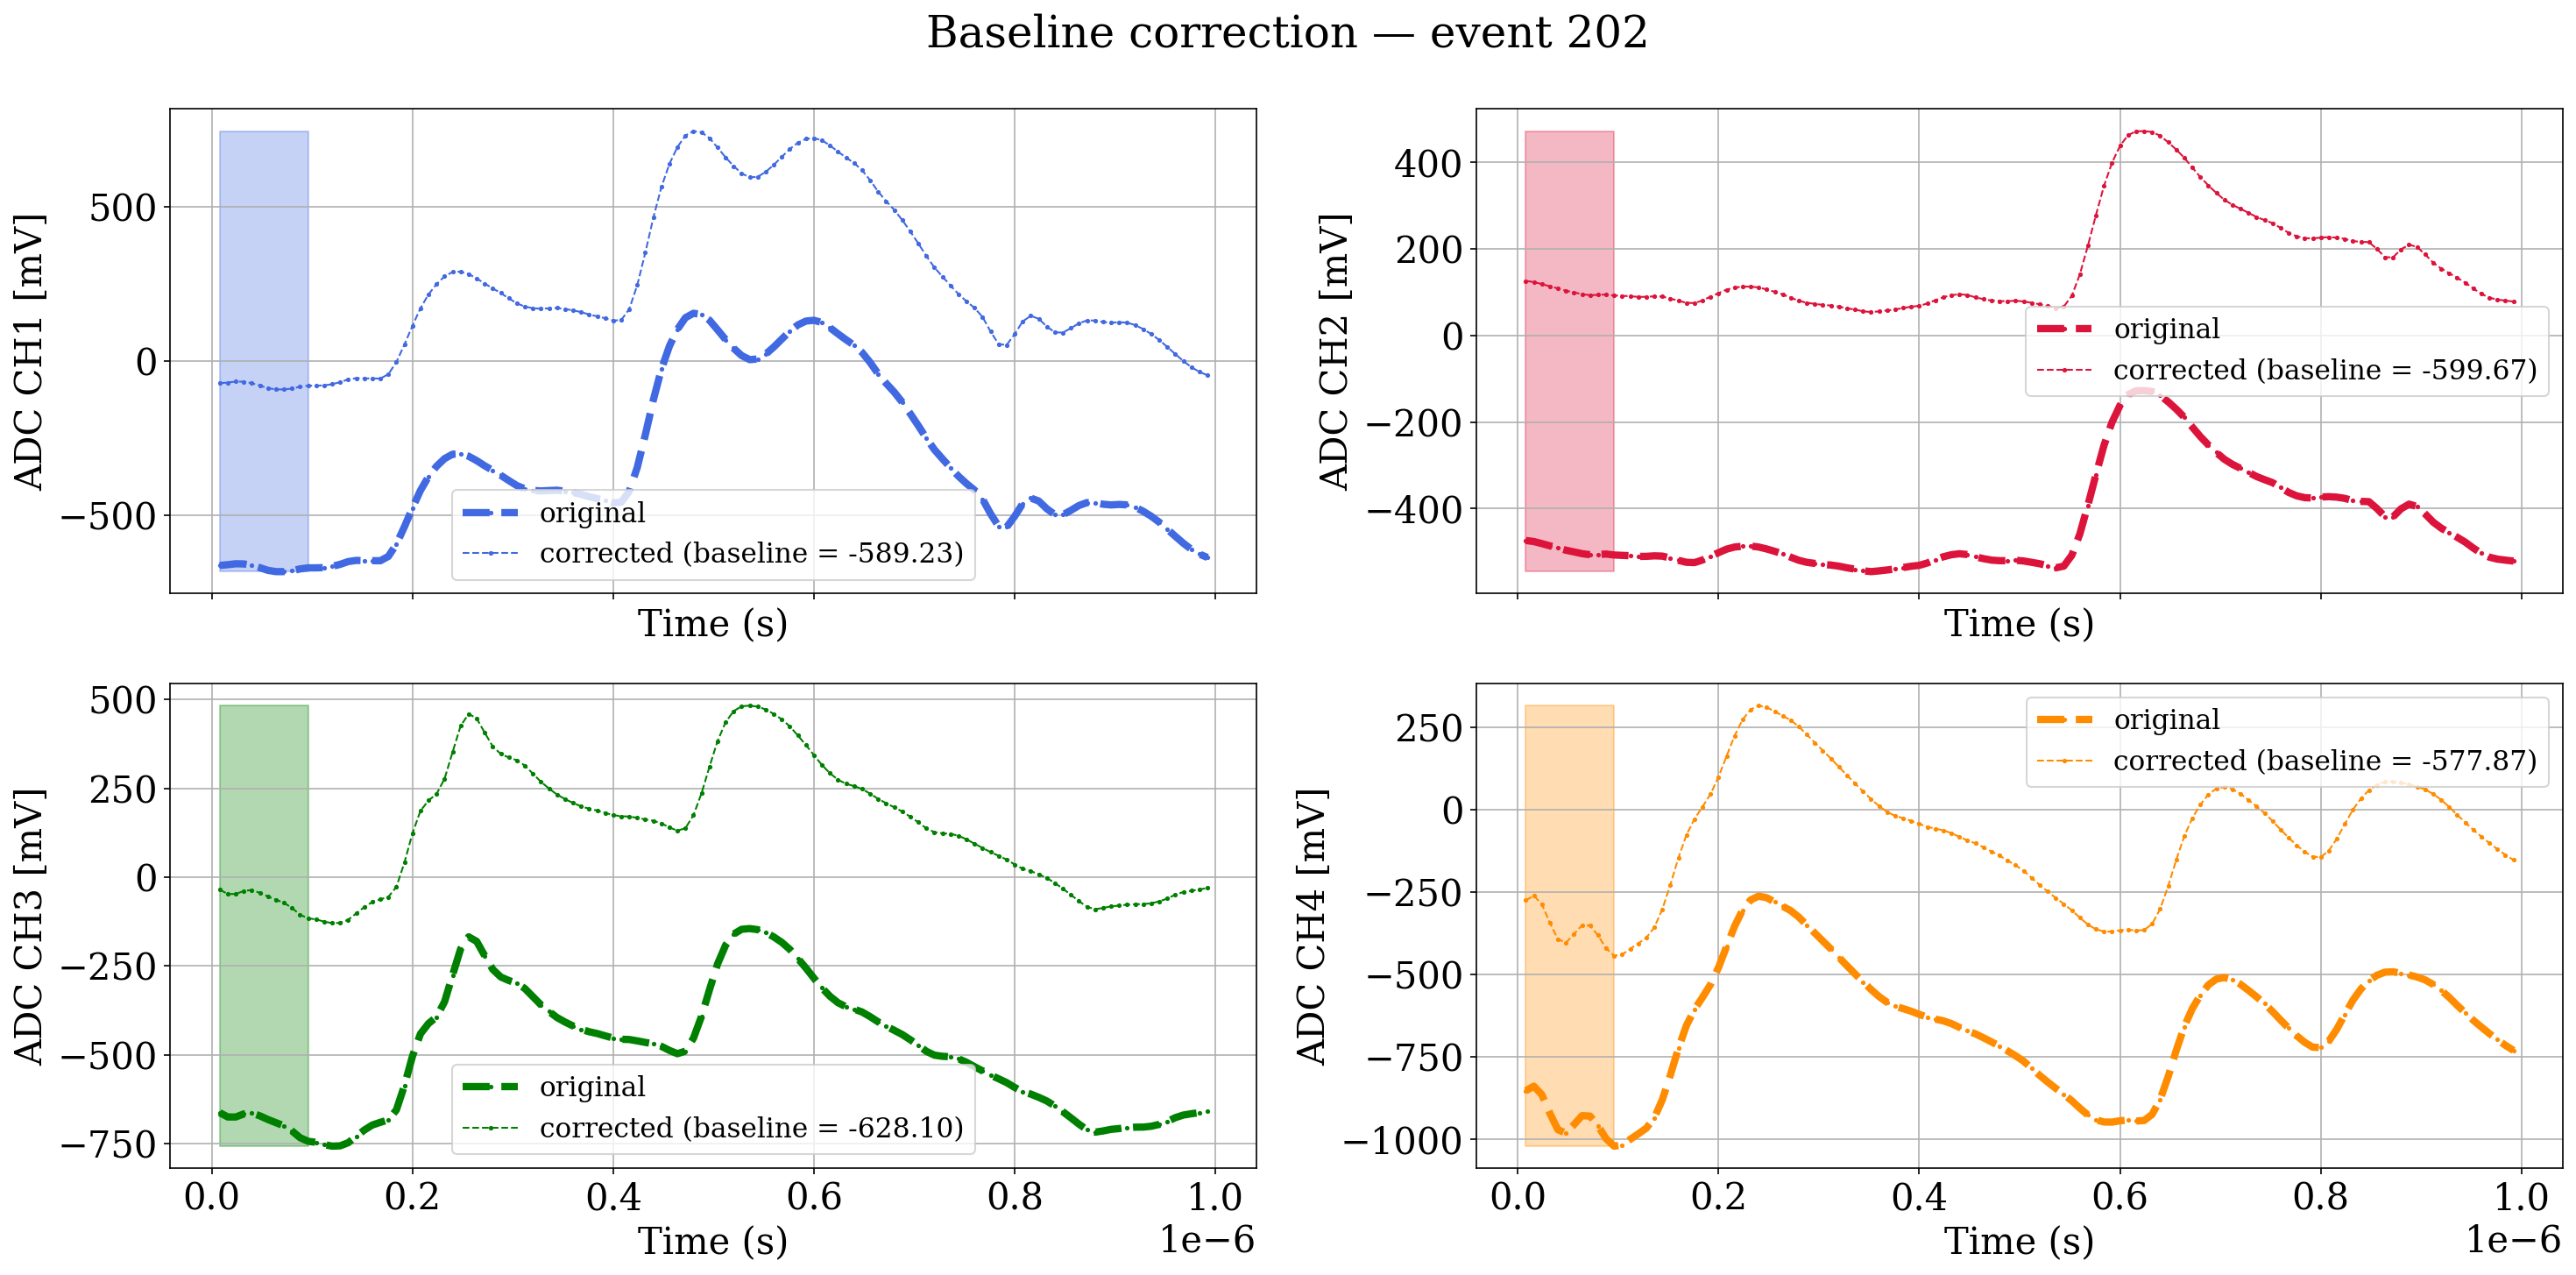

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Baseline correction — event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage    = filtered_df[ch].values
    v_matrix   = voltage.reshape(nevents, -1)
#     v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)
    v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
    window = pretrigger

    ax.plot(t_matrix[selected_event], v_matrix[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=4, label='original')
    ax.plot(t_matrix[selected_event], v_matrix_corrected[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=1,
            label=f'corrected (baseline = {fixBaselines_Amp[ch]:.2f})')

    ax.fill_between(time[:pretrigger],
                    v_matrix[selected_event].min(),
                    v_matrix_corrected[selected_event].max(),
                    color=colors[i], alpha=0.3)

    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend(fontsize=15)

plt.tight_layout()
plt.show()


In [19]:
# time_window = (0.18e-6 < time) & (time <= 0.45e-6)
time_window = (0.18e-6 < time) & (time <= 0.6e-6)
time_window = (0.18e-6 < time) & (time <= 0.8e-6)
# time_window = (0.18e-6 < time) & (time <= 0.7e-6)

# time_window = (-1 < time)
# time_window = (0.18e-6 < time) 




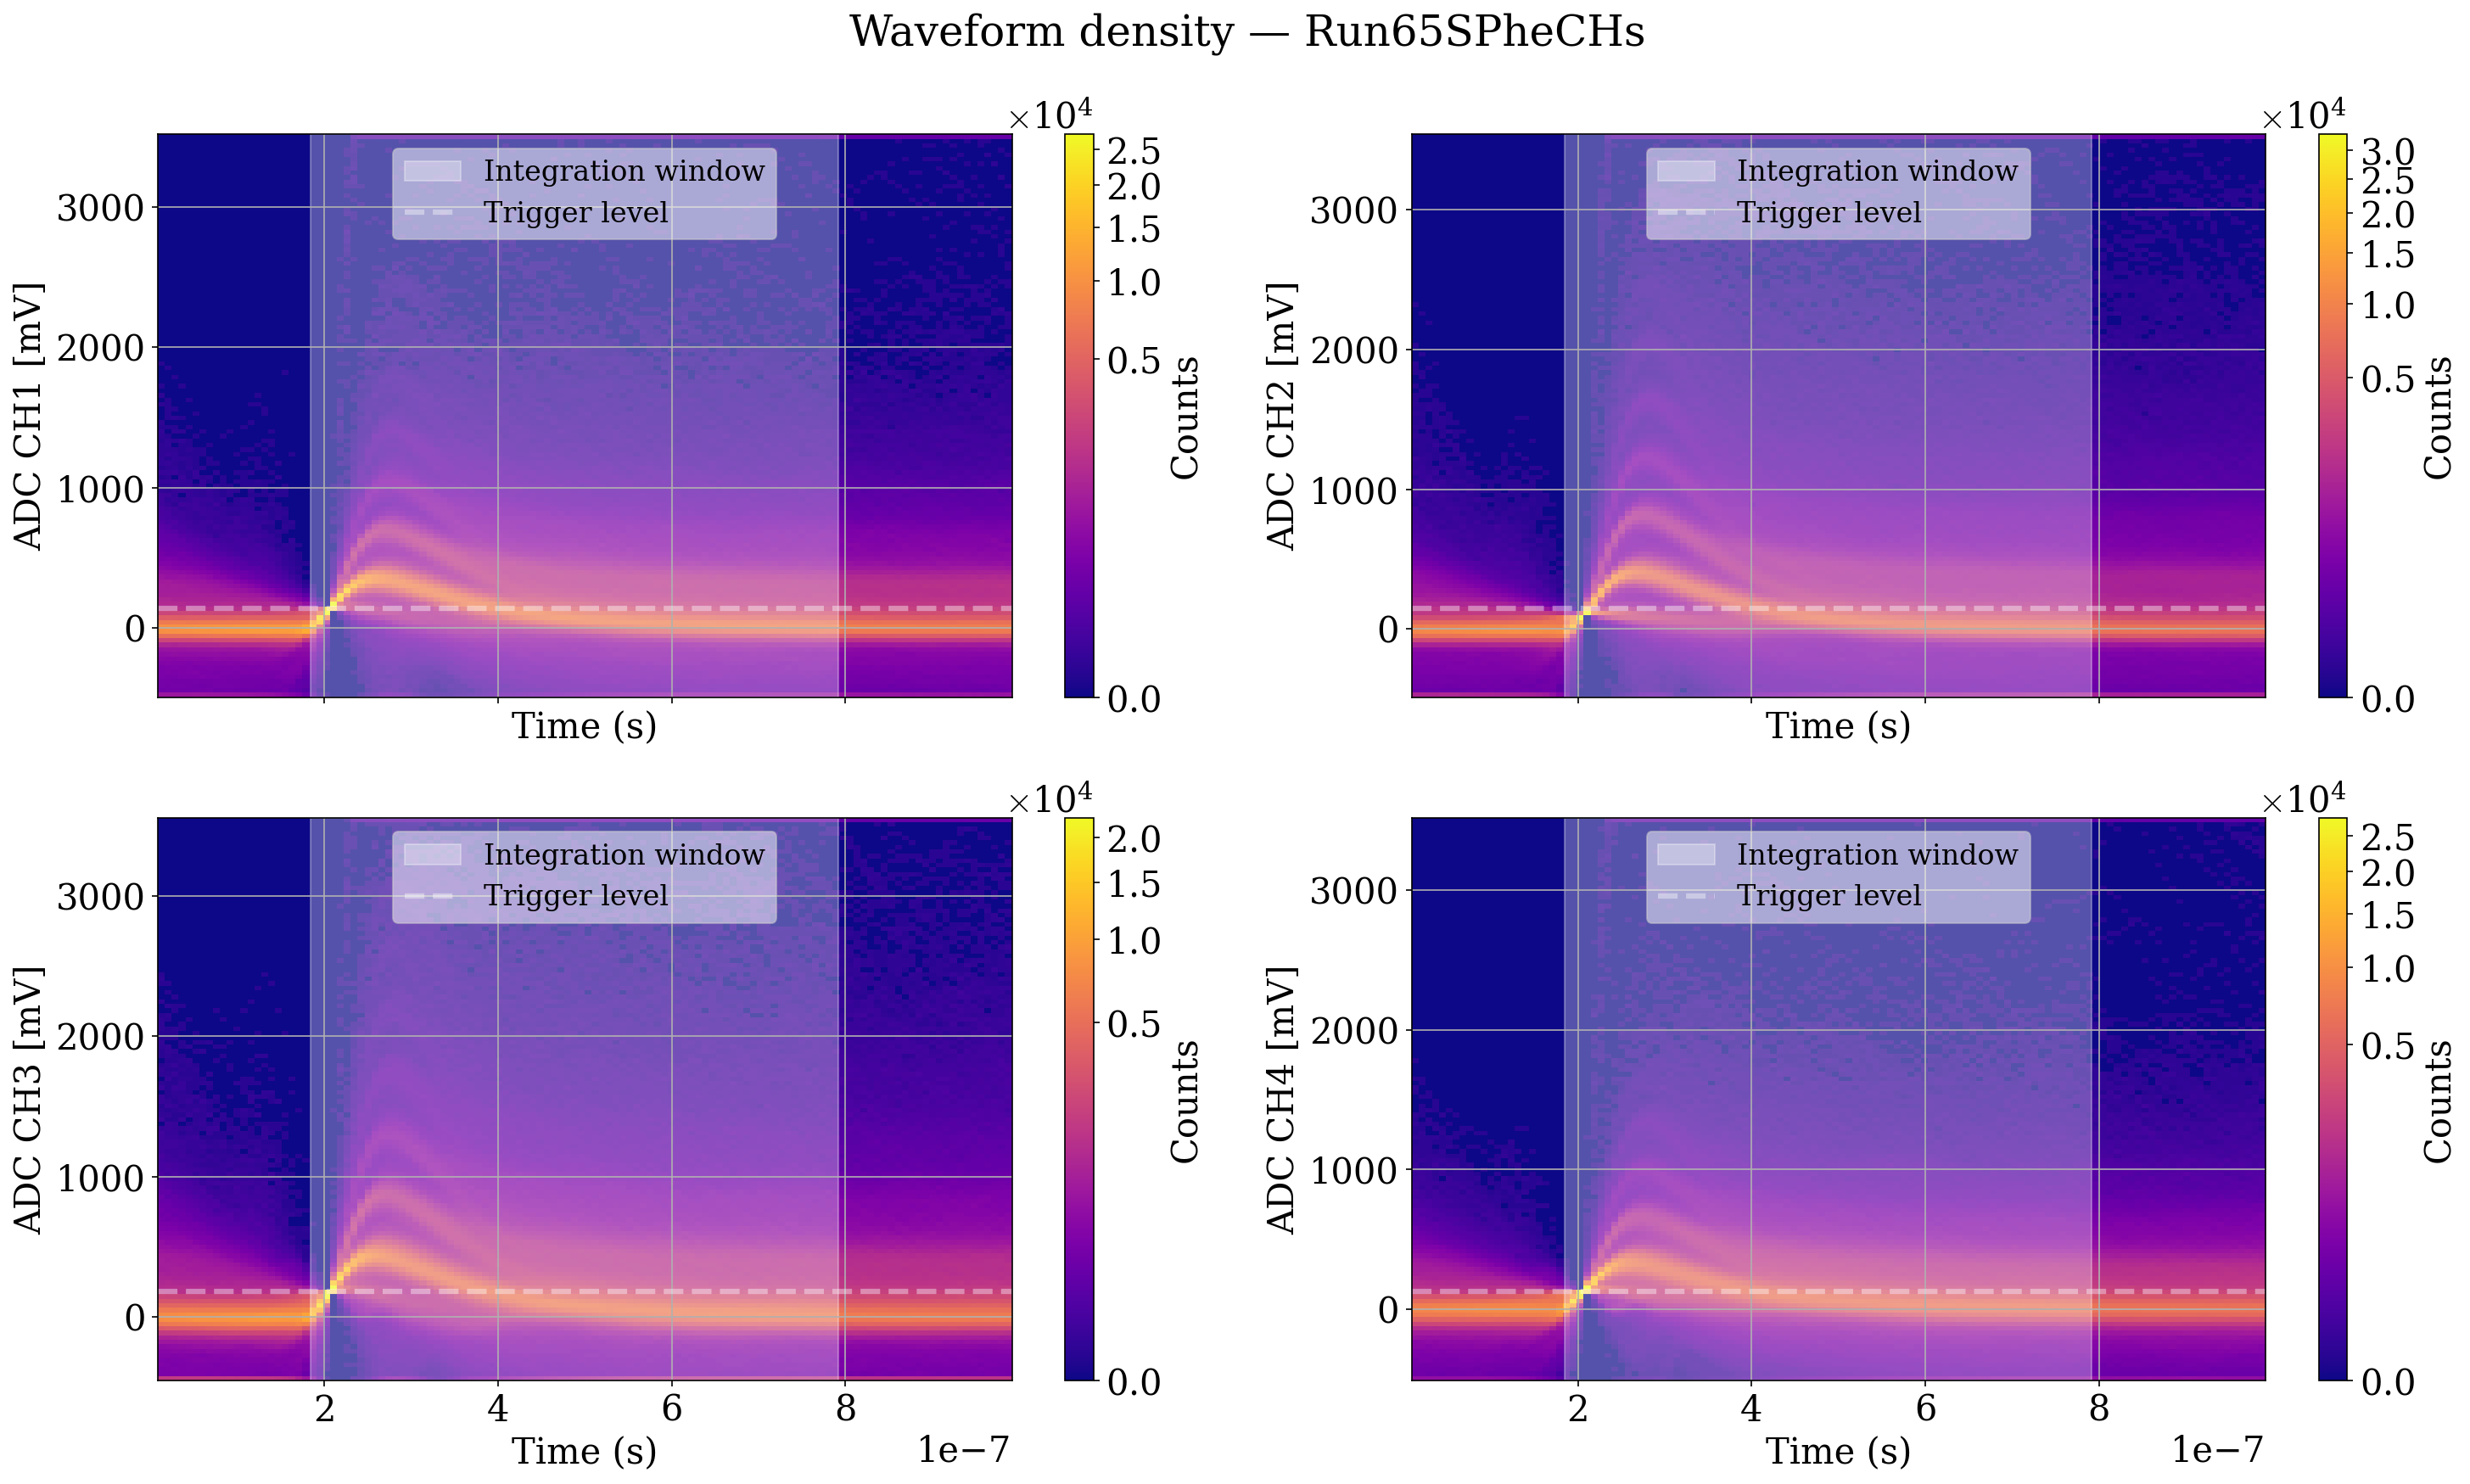

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Waveform density — {run_base}s')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage            = filtered_df[ch].values
    v_matrix           = voltage.reshape(nevents, -1)
    v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
    # v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)


    hb = ax.hist2d(t_matrix.flatten(), v_matrix_corrected.flatten(),
                   bins=[np.shape(t_matrix)[1], np.shape(v_matrix_corrected)[1]],
                   cmap='plasma', norm=mcolors.PowerNorm(gamma=0.3))
    cbar = fig.colorbar(hb[3], ax=ax, label='Counts')
    cbar.formatter.set_powerlimits((0,0))
    cbar.formatter.set_useMathText(True)


    ax.fill_between(time[time_window],
                    v_matrix_corrected.min(), v_matrix_corrected.max(),
                    color='white', alpha=0.3, label='Integration window')
    
    ax.axhline(-fixBaselines_Amp[ch] - 450, color='white', alpha = 0.4, linestyle='--', lw=3, label='Trigger level')


    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    # ax.set_ylim(0, 700)
    ax.legend(framealpha=0.5, fontsize=font_size*0.8)

plt.tight_layout()
plt.show()


In [21]:
save = False
if save:
    mean_waveforms = {}
    for i, ch in enumerate(channels):
        voltage              = filtered_df[ch].values
        v_matrix             = voltage.reshape(nevents, -1)
        # v_matrix_corrected   = v_matrix - fixBaselines_Amp[ch]
        v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)

        # keep only events whose maximum sample exceeds threshold
        threshold      = 300   # [mV]
        mask           = v_matrix_corrected.max(axis=1) > threshold
        n_above        = mask.sum()
        print(f'{ch}: {n_above}/{nevents} events with peak > {threshold} mV')

        mean_waveforms[ch] = np.mean(v_matrix_corrected[mask], axis=0)

        run = f'{run_base}{i+1}'
        np.savez(f'{base}/mean_waveforms/mean_waveforms_{run}.npz',
                 **{f'ch_{ch}': mean_waveforms[ch]},
                 time          = time,
                 channels      = np.array([ch]),
                 time_window   = time_window,
                 threshold     = threshold,
                 n_events_used = n_above)
        print(f'Saved mean waveforms to mean_waveforms_{run}.npz')

In [22]:
run_base

'Run65SPheCH'

In [23]:
channels

['CH1', 'CH2', 'CH3', 'CH4']

# CHARGE

##  Finger Plot

In [24]:
def FingerPlot(df, channels, n_gaussians_list, hist_range_percentile=99, test = False):
    """
    Charge finger plot for all channels in a 2x2 grid.

    hist_range_percentile sets the histogram's upper edge dynamically, as
    a percentile of that channel's own charge distribution (0, so it
    still starts at the pedestal) instead of a hardcoded absolute value
    tuned to one particular run - different runs/gases have very
    different charge scales, and a fixed range either clips the peaks off
    or squashes them into a corner. A percentile is used rather than the
    raw max so a single extreme outlier (a rare huge afterpulse/cosmic
    event) can't blow the range out and hide the peaks - which is exactly
    what "percentage of the max value" would do.
    """

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}
    # fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig, axs = plt.subplots(2, 2, figsize=(40, 16), dpi=150)
    fig.suptitle(f'{run_base}s ({gas} @ {pressure}bar + {temperature}) — Charge Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]
        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]
        # v_matrix_corrected, _, _ = cig.BaselineCorrection(v_matrix, window=window_width)

        n_gaussians = n_gaussians_list[i]
        charge = np.trapz(v_matrix_corrected[:, time_window],
                          x=time[time_window], axis=1)

        hist_range = (0, np.percentile(charge, hist_range_percentile))
        # hist_range = (0, 5e-4)

        if test:
            hist_range = None
            opt_A, opt_mu, opt_sigma, opt_mu_errors = None, None, None, None
        

        events_hist, bins, _ = ax.hist(charge,
                                       bins=int(0.5*np.sqrt(len(charge))),
                                       range=hist_range,
                                       density=False,
                                       color=colors[i],
                                       alpha=0.3,
                                       label=ch)
        
        bins_means = (bins[:-1] + bins[1:]) / 2
        # peak_distance = 40 if i < 2 else 60
        peak_distance = 15 if i < 2 else 20
        peaks, _ = find_peaks(events_hist, distance=peak_distance, prominence=0.6)
        ax.plot(bins_means[peaks], events_hist[peaks], 'or', markersize=20, alpha=0.3)

        if not test:
            msk = ((bins_means > (bins_means[events_hist.argmax()] + bins_means[0]) * 0.05) &
                (bins_means < bins_means[peaks[n_gaussians - 1]] * 1.15))
            x = bins_means[msk]
            y = events_hist[msk]
            initial_guess_A     = list(events_hist[peaks][:n_gaussians])
            initial_guess_mu    = list(bins_means[peaks][:n_gaussians])
            initial_guess_sigma = [0.6 * (bins_means[1] - bins_means[0])] * n_gaussians
            initial_guess       = initial_guess_A + initial_guess_mu + initial_guess_sigma
            params, covariance = curve_fit(cig.sum_of_gaussians, x, y, p0=initial_guess, maxfev=100000)
            for j in range(10):
                lower  = np.minimum(params * 0.8, params * 1.2)
                upper  = np.maximum(params * 0.8, params * 1.2)
                bounds = (lower, upper)
                params, covariance = curve_fit(cig.sum_of_gaussians, x, y,
                                            p0=params, bounds=bounds, maxfev=100000)
            opt_A[ch]         = params[:n_gaussians]
            opt_mu[ch]        = params[n_gaussians:2*n_gaussians]
            opt_sigma[ch]     = params[2*n_gaussians:]
            opt_mu_errors[ch] = np.sqrt(np.diag(covariance)[n_gaussians:2*n_gaussians])
            gaussian_sum = cig.sum_of_gaussians(x, *params)
            ax.plot(x, gaussian_sum, color=colors[i], lw=3, alpha=1, label='Gaussian Fit')

            for jj, mu in enumerate(opt_mu[ch]):
                y_marker = cig.sum_of_gaussians(mu, *params)
                one_g    = [opt_A[ch][jj], opt_mu[ch][jj], opt_sigma[ch][jj]]
                ax.plot(mu, y_marker, 'X', color='k', markersize=10, zorder=5)  # no label
                ax.plot(x, cig.sum_of_gaussians(x, *one_g), '--', color='k')
                ax.annotate(fr'$\mu_{{{jj+1}}}$={mu:.2E}',         # <-- text above marker
                            xy=(mu, y_marker),
                            xytext=(0, 12), 
                            textcoords='offset points',
                            ha='center', 
                            va='bottom', 
                            fontsize=font_size*0.8,
                            color='k'
                            )

        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))  # <-- sci notation
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

        ax.set_title(ch)
        ax.set_xlabel(r'Charge [mV·s]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=font_size)

    plt.tight_layout()
    plt.show()
    return opt_A, opt_mu, opt_sigma, opt_mu_errors

/tmp/ipykernel_16582/1096846939.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  charge = np.trapz(v_matrix_corrected[:, time_window],


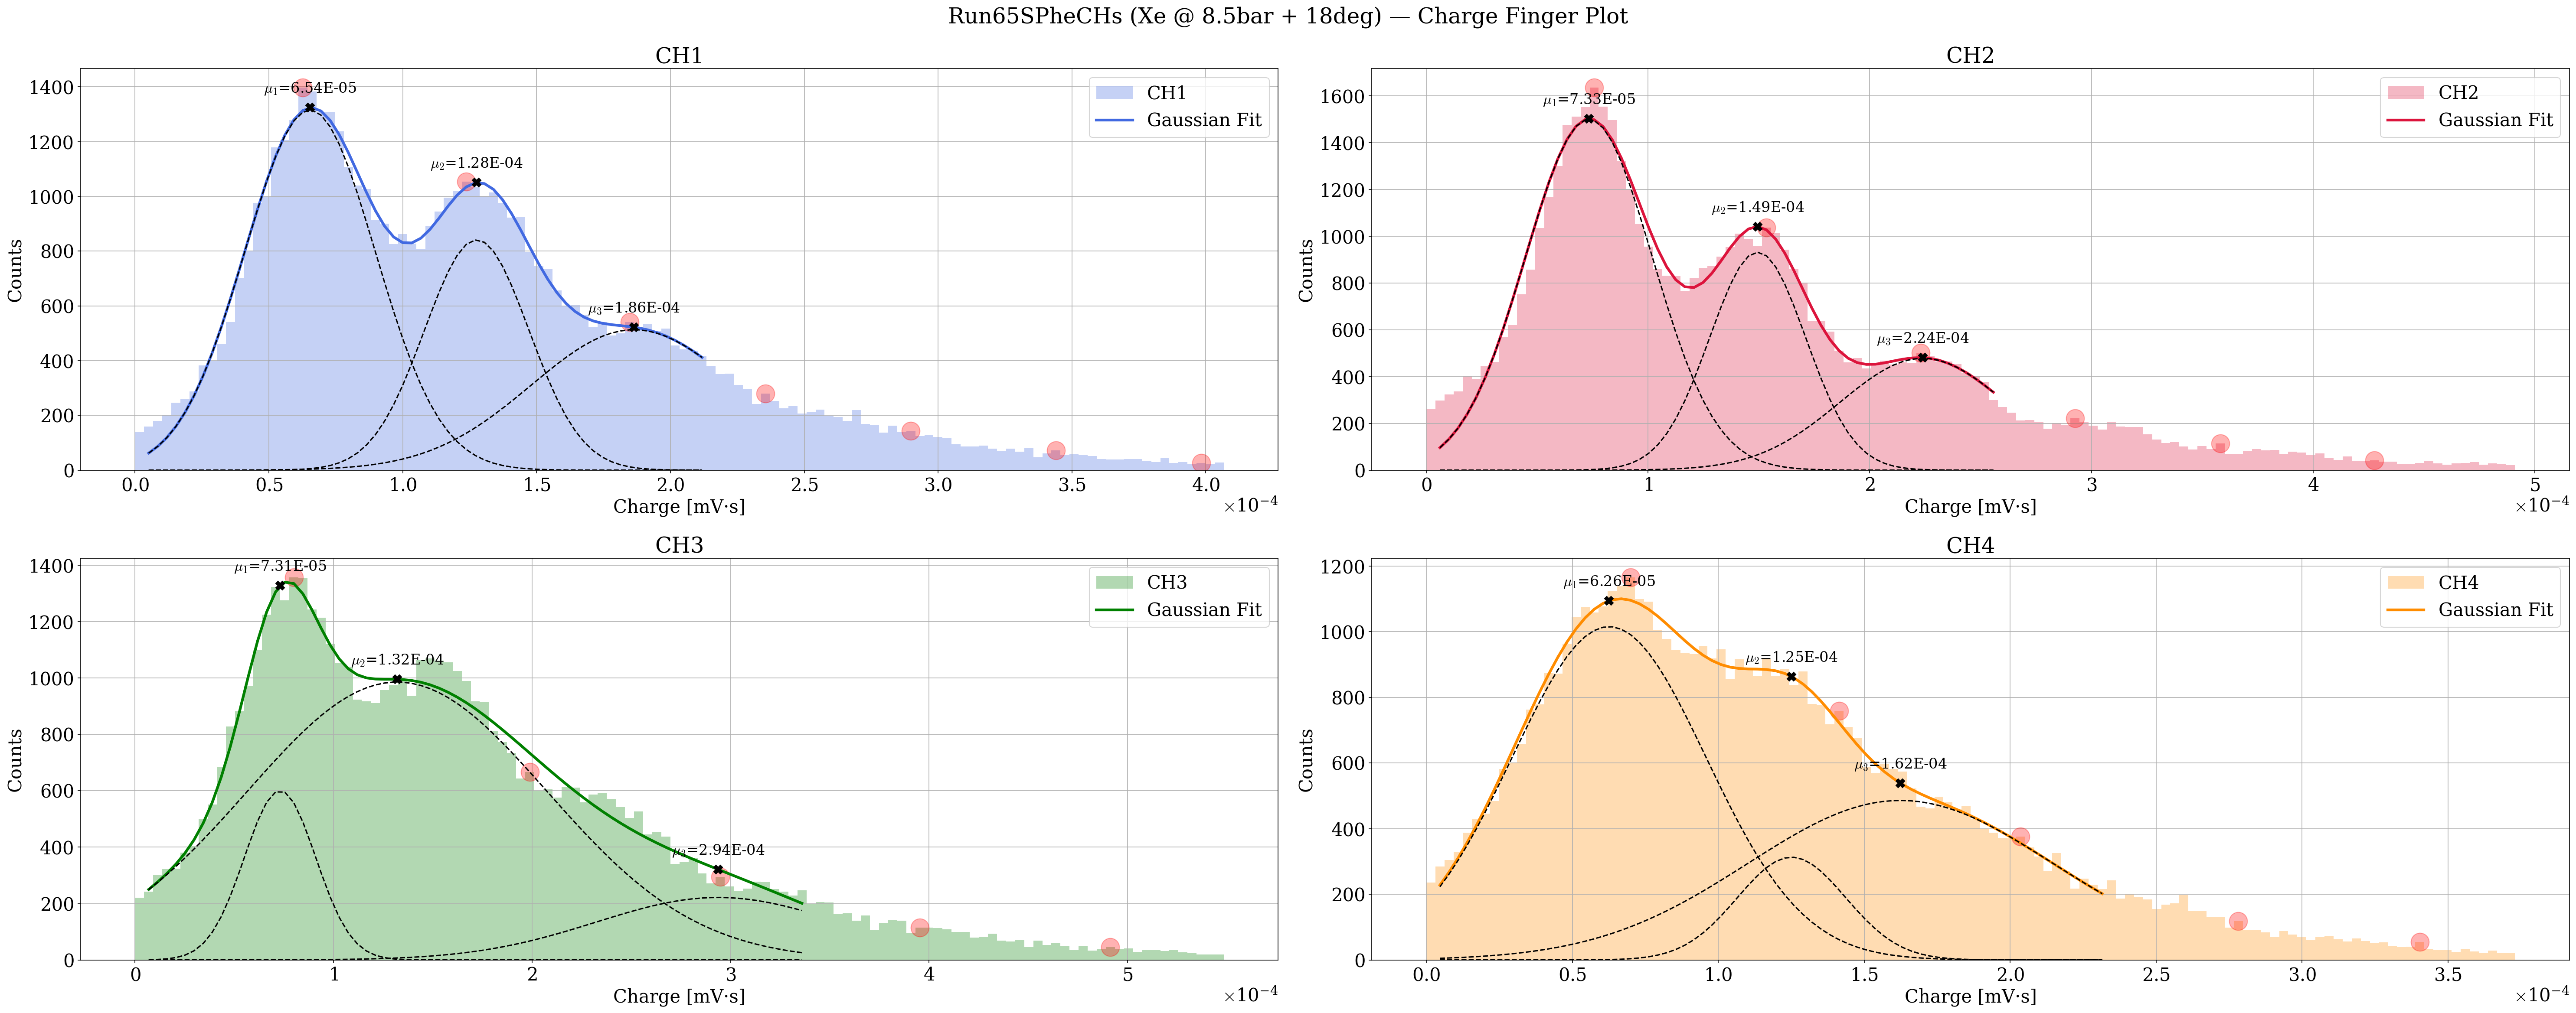

In [26]:
# n_gaussians = [4, 4, 4, 4]
n_gaussians = [3]*4
opt_A, opt_mu, opt_sigma, opt_mu_errors = FingerPlot(filtered_df, channels, n_gaussians, test=False)


In [ ]:
# The Gaussians in opt_* are ordered by increasing charge (peak 1 = lowest).
# If peak 1 is shorter than peak 2, it's the pedestal (0 p.e.), not the
# 1-p.e. peak - drop it so the peaks fed into DCR/linearity below start at
# N_pe = 1, otherwise the Poisson fit and linearity would be shifted by
# one peak and the DCR would come out wrong.
for ch in opt_A:
    if opt_A[ch][0] < opt_A[ch][1]:
        print(f'{ch}: peak 1 is shorter than peak 2 -> treating peak 1 as the noise pedestal (0 p.e.) and dropping it')
        opt_A[ch]         = opt_A[ch][1:]
        opt_mu[ch]        = opt_mu[ch][1:]
        opt_sigma[ch]     = opt_sigma[ch][1:]
        opt_mu_errors[ch] = opt_mu_errors[ch][1:]


CH3: peak 1 is shorter than peak 2 -> treating peak 1 as the noise pedestal (0 p.e.) and dropping it


##  DCR

In [ ]:
def calculate_DCR(opt_A, opt_mu, opt_sigma, window_width_time, plot=True):
    """
    Fit each channel's charge-peak areas (Npe = 1, 2, 3, ...) to a Poisson
    distribution and convert the fitted mean into a Dark Count Rate.

    Each Gaussian from FingerPlot is unnormalized (A = peak height, not
    area), so the "number of counts" under peak j is its integral
    A_j * sigma_j * sqrt(2*pi), not A_j alone. mu_fit (the Poisson mean
    number of p.e. per integration window) divided by the window width [s]
    gives the DCR [Hz].

    Parameters
    ----------
    opt_A, opt_mu, opt_sigma : dict of {channel: array}
        FingerPlot's fitted Gaussian parameters (per channel, per peak).
    window_width_time : float
        Width [s] of the charge-integration window used to build the
        finger plot (e.g. time[time_window][-1] - time[time_window][0]).
    plot : bool
        If True, draw the peak-area data and Poisson fit for each channel
        in a 2x2 grid, with the DCR (in MHz) annotated in a text box.

    Returns
    -------
    DCR, DCR_err : dict of {channel: float}
        Dark count rate and its uncertainty [Hz], per channel.
    poisson_params : dict of {channel: array([A, mu])}
        Raw Poisson fit parameters, per channel.
    """
    DCR, DCR_err, poisson_params = {}, {}, {}

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
        fig.suptitle(f'Dark Count Rate — {run_base}s ({gas} @ {pressure}bar + {temperature})')
        axs_flat = axs.flatten()

    for idx, ch in enumerate(opt_A.keys()):
        # Order peaks by charge (Npe = 1, 2, 3, ...) and turn each Gaussian
        # into its area (= total counts under that peak), not just its height.
        order  = np.argsort(opt_mu[ch])
        npe    = np.arange(len(order)) + 1
        counts = (opt_A[ch] * opt_sigma[ch] * np.sqrt(2 * np.pi))[order]

        p0     = [counts.max(), np.sum(npe * counts) / np.sum(counts)]
        bounds = ([0, 1e-6], [np.inf, np.inf])   # A >= 0, mu > 0 (poisson_continuous needs log(mu))
        params, covariance = curve_fit(cig.poisson_continuous, npe, counts, p0=p0, bounds=bounds, maxfev=100000)
        mu_fit, mu_fit_err = params[1], np.sqrt(covariance[1, 1])

        DCR[ch]            = mu_fit / window_width_time
        DCR_err[ch]        = mu_fit_err / window_width_time
        poisson_params[ch] = params

        if plot:
            ax = axs_flat[idx]
            npe_fit = np.linspace(1, npe.max(), 200)
            ax.plot(npe, counts, 'o', color='k', markersize=12, label='Peak area (counts)')
            ax.plot(npe_fit, cig.poisson_continuous(npe_fit, *params), color=colors[idx], lw=3,
                    label=fr'Poisson fit: $\mu$ = {mu_fit:.2f} $\pm$ {mu_fit_err:.2f}')

            ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

            DCR_MHz     = DCR[ch] / 1e6
            DCR_err_MHz = DCR_err[ch] / 1e6
            ax.text(0.4, 0.3, f'DCR = ({DCR_MHz:.2f} ± {DCR_err_MHz:.2f}) MHz',
                    transform=ax.transAxes, ha='right', va='top', fontsize=font_size * 0.8,
                    bbox=dict(boxstyle='round', facecolor='white', edgecolor='k', alpha=0.8))

            ax.set_title(ch, fontsize=font_size)
            ax.set_xlabel(r'$N_{pe}$', fontsize=font_size)
            ax.set_ylabel('Counts (peak area)', fontsize=font_size)
            ax.grid(True)
            ax.legend(fontsize=font_size * 0.7, loc='upper right')

    if plot:
        plt.show()

    return DCR, DCR_err, poisson_params

/tmp/ipykernel_9272/3884679039.py:46: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(cig.poisson_continuous, npe, counts, p0=p0, bounds=bounds, maxfev=100000)


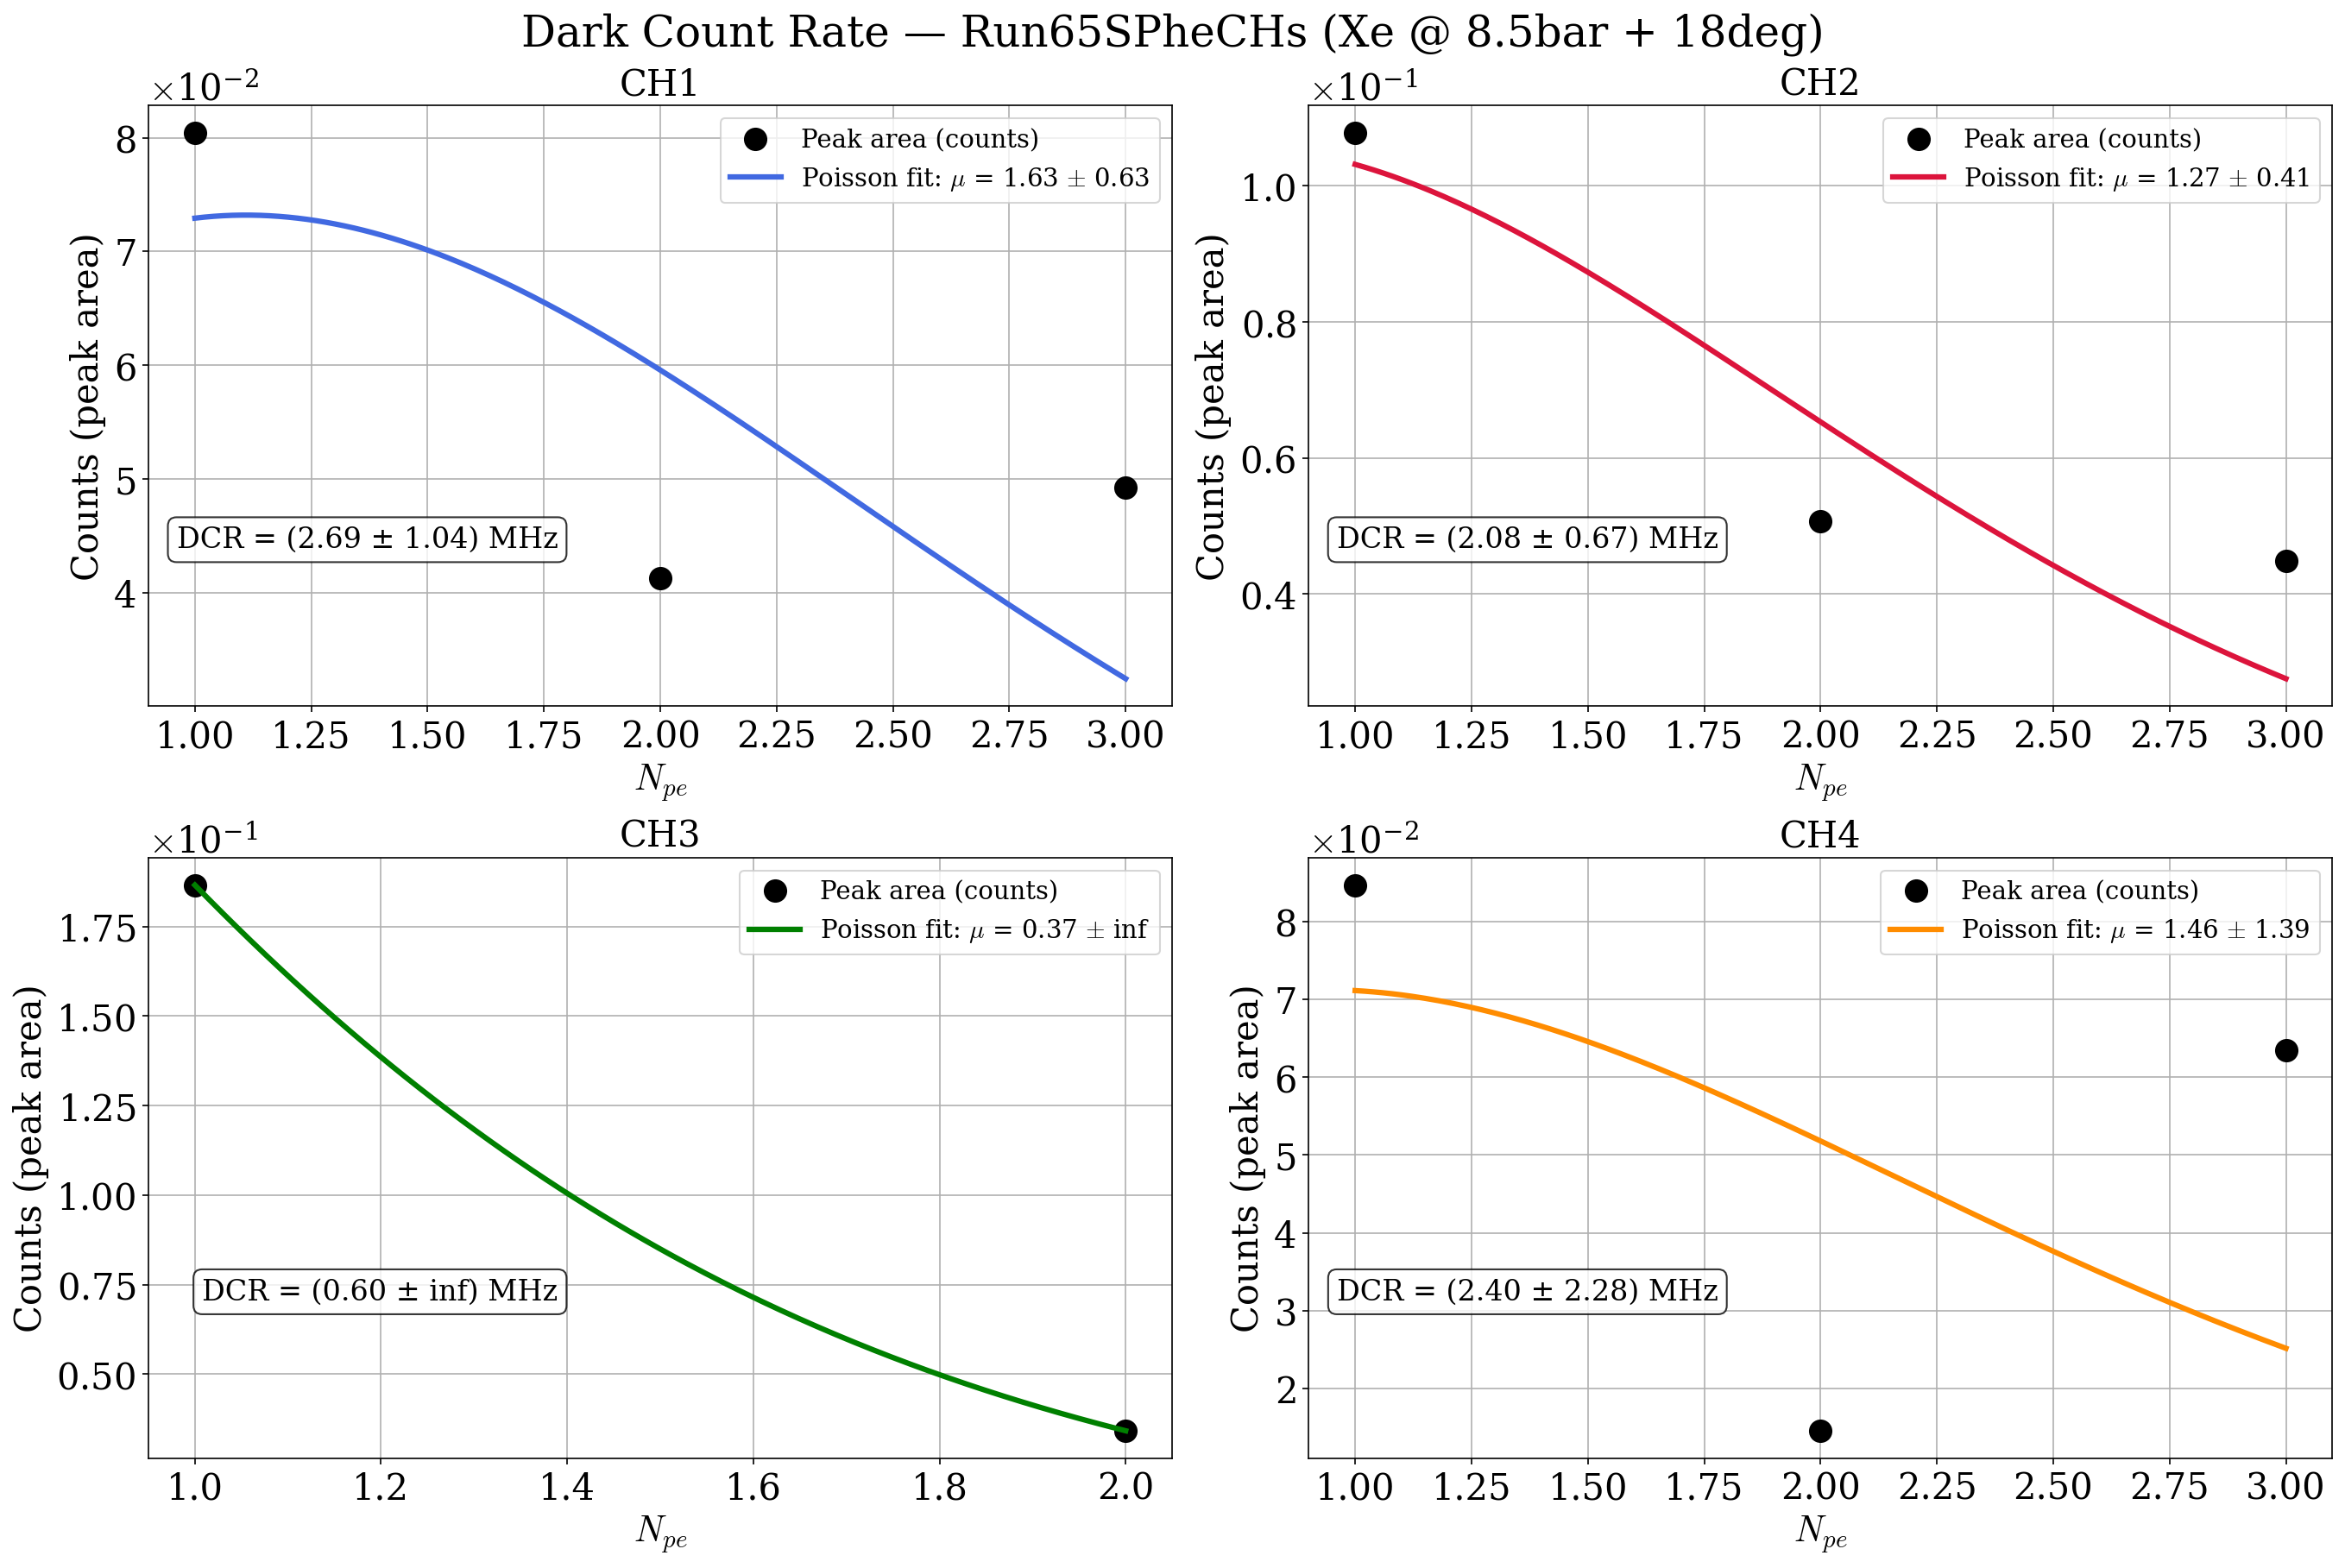

CH1: DCR = (2.687E+06 ± 1.0E+06) Hz  (integration window = 6.08E-07 s)
CH2: DCR = (2.083E+06 ± 6.7E+05) Hz  (integration window = 6.08E-07 s)
CH3: DCR = (6.021E+05 ± INF) Hz  (integration window = 6.08E-07 s)
CH4: DCR = (2.395E+06 ± 2.3E+06) Hz  (integration window = 6.08E-07 s)


In [ ]:
window_width_time = time[time_window][-1] - time[time_window][0]

DCR, DCR_err, poisson_params = calculate_DCR(opt_A, opt_mu, opt_sigma, window_width_time)

for ch in DCR:
    print(f'{ch}: DCR = ({DCR[ch]:.3E} ± {DCR_err[ch]:.1E}) Hz  (integration window = {window_width_time:.2E} s)')

##  Data Analysis: Linearity

In [ ]:
opt_mu


{'CH1': array([0.00010892, 0.00018885, 0.00066219, 0.0009543 ]),
 'CH2': array([7.15915074e-05, 1.46000390e-04, 2.25428177e-04, 1.87195783e-04,
        8.28274804e-04]),
 'CH3': array([0.00050522, 0.00062733]),
 'CH4': array([8.78279459e-05, 1.71975163e-04, 7.12968073e-04, 9.87222795e-04])}

In [ ]:
pes_spectrum = opt_mu
err_spectrum = opt_mu_errors


In [ ]:
# npeaks = -1  # all except last one
npeaks = None   # all


ValueError: the number of data points must exceed order to scale the covariance matrix

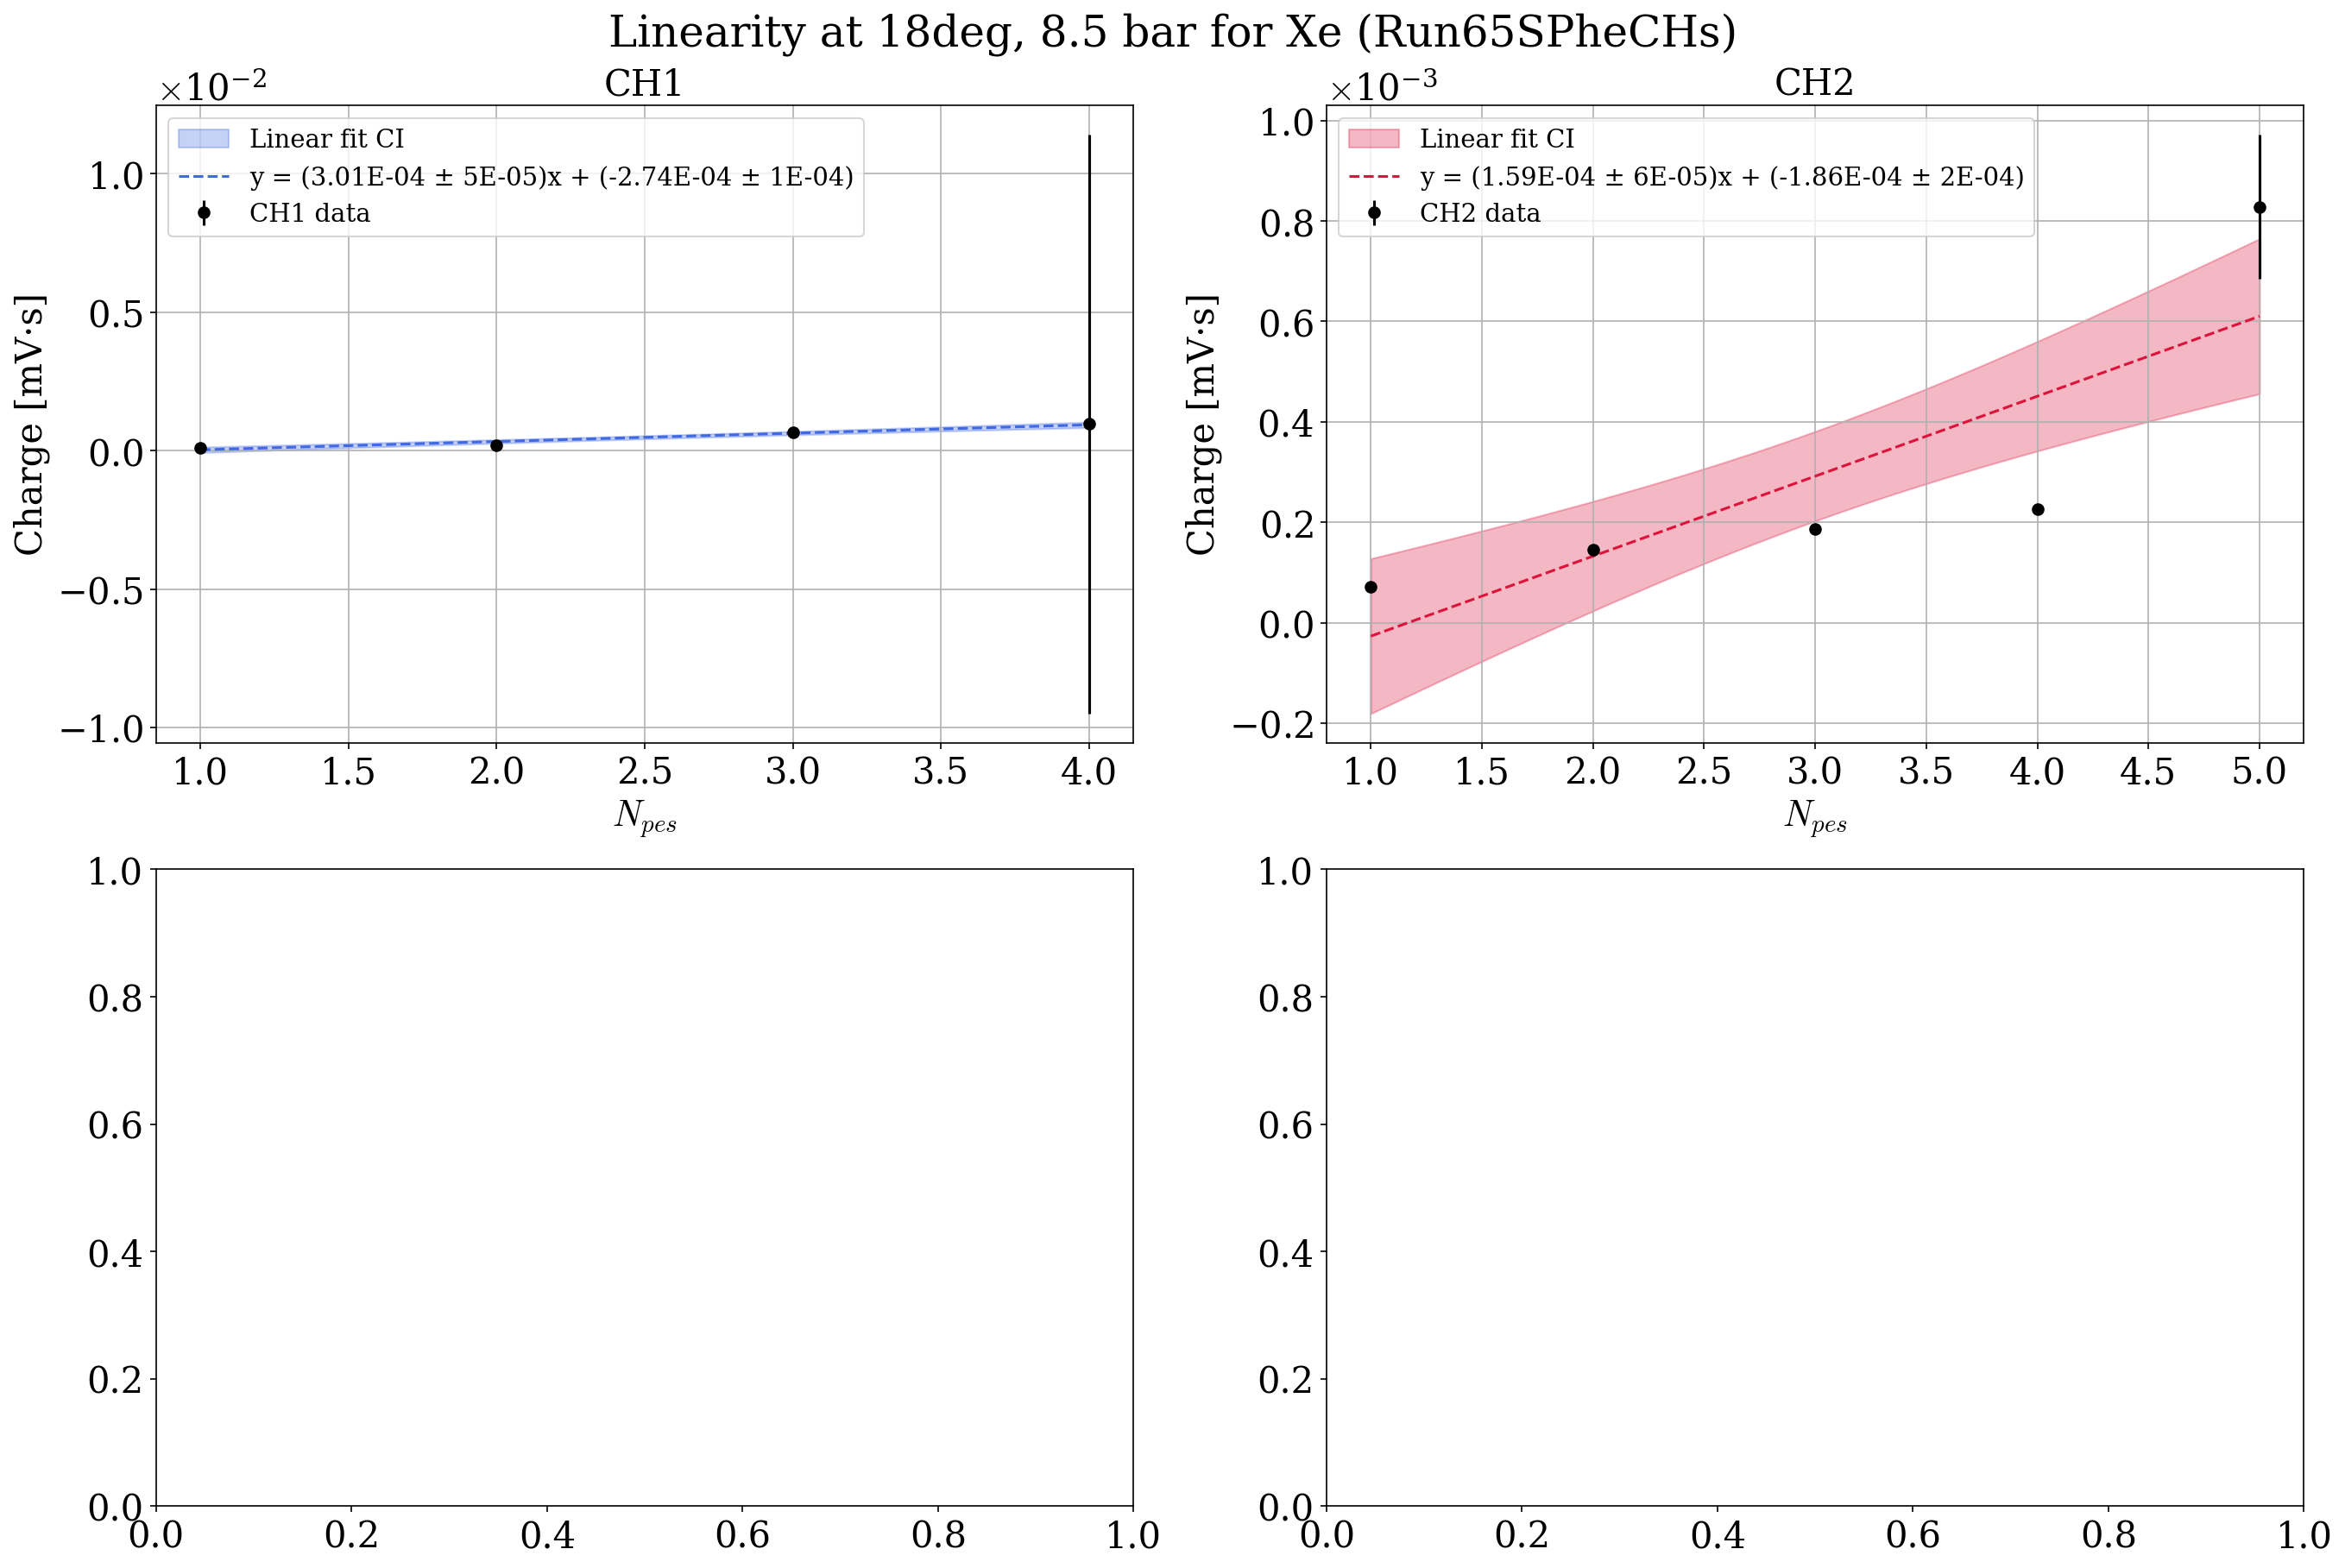

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
fig.suptitle(f'Linearity at {temperature}, {pressure} bar for {gas} ({run_base}s)')
axs_flat = axs.flatten()

for idx, ch in enumerate(pes_spectrum.keys()):
    ax = axs_flat[idx]

    x = np.arange(len(pes_spectrum[ch][:npeaks])) + 1
    y = pes_spectrum[ch][:npeaks]
    order = np.argsort(y)
    y = y[order]

    params, cov = np.polyfit(x, y, 1, cov=True)
    slope, intercept = params
    slope_err     = np.sqrt(cov[0, 0])
    intercept_err = np.sqrt(cov[1, 1])

    x_fit     = np.linspace(min(x), max(x), 200)
    y_fit     = slope * x_fit + intercept
    y_fit_var = (x_fit**2) * cov[0,0] + cov[1,1] + 2 * x_fit * cov[0,1]
    y_fit_err = np.sqrt(y_fit_var)

    ax.errorbar(x, y, yerr=err_spectrum[ch][:npeaks][order],
                fmt='o', alpha=1, color='k', label=f'{ch} data')
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
                    color=colors[idx], alpha=0.3, label='Linear fit CI')
    ax.plot(x_fit, y_fit, color=colors[idx], linestyle='--',
            label=f'y = ({slope:.2E} ± {slope_err:.0E})x + ({intercept:.2E} ± {intercept_err:.0E})')


    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))  # <-- sci notation
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    
    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel(r'$N_{pes}$', fontsize=font_size)
    ax.set_ylabel(r'Charge [mV·s]', fontsize=font_size)
    ax.grid(True)
    ax.legend(fontsize=font_size*0.7, loc='upper left')

plt.show()


# PEAK VOLTAGE

##  Finger Plot

In [ ]:
def FingerPlotVoltage(df, channels, n_gaussians):
    """Peak-voltage finger plot for all channels in a 2x2 grid."""

    voltage_opt_A, voltage_opt_mu, voltage_opt_sigma, voltage_opt_mu_errors = {}, {}, {}, {}

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig.suptitle(f'{run_base} — Peak Voltage Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]

        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]

        peak_mV = np.max(v_matrix[:, time_window], axis=1)

        events_hist, bins, _ = ax.hist(peak_mV,
                                       bins=int(np.sqrt(len(peak_mV))),
                                       range=(-460, 1000),
                                       density=False,
                                       color=colors[i],
                                       alpha=0.3,
                                       label=ch)

        bins_means = (bins[:-1] + bins[1:]) / 2

        ax.axvline(200, color='red', linestyle='--', lw=2, label='Current signal trigger')

        ax.set_title(ch)
        ax.set_xlabel('Peak value [mV]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=font_size)

    plt.tight_layout()
    plt.show()

    return voltage_opt_A, voltage_opt_mu, voltage_opt_sigma, voltage_opt_mu_errors


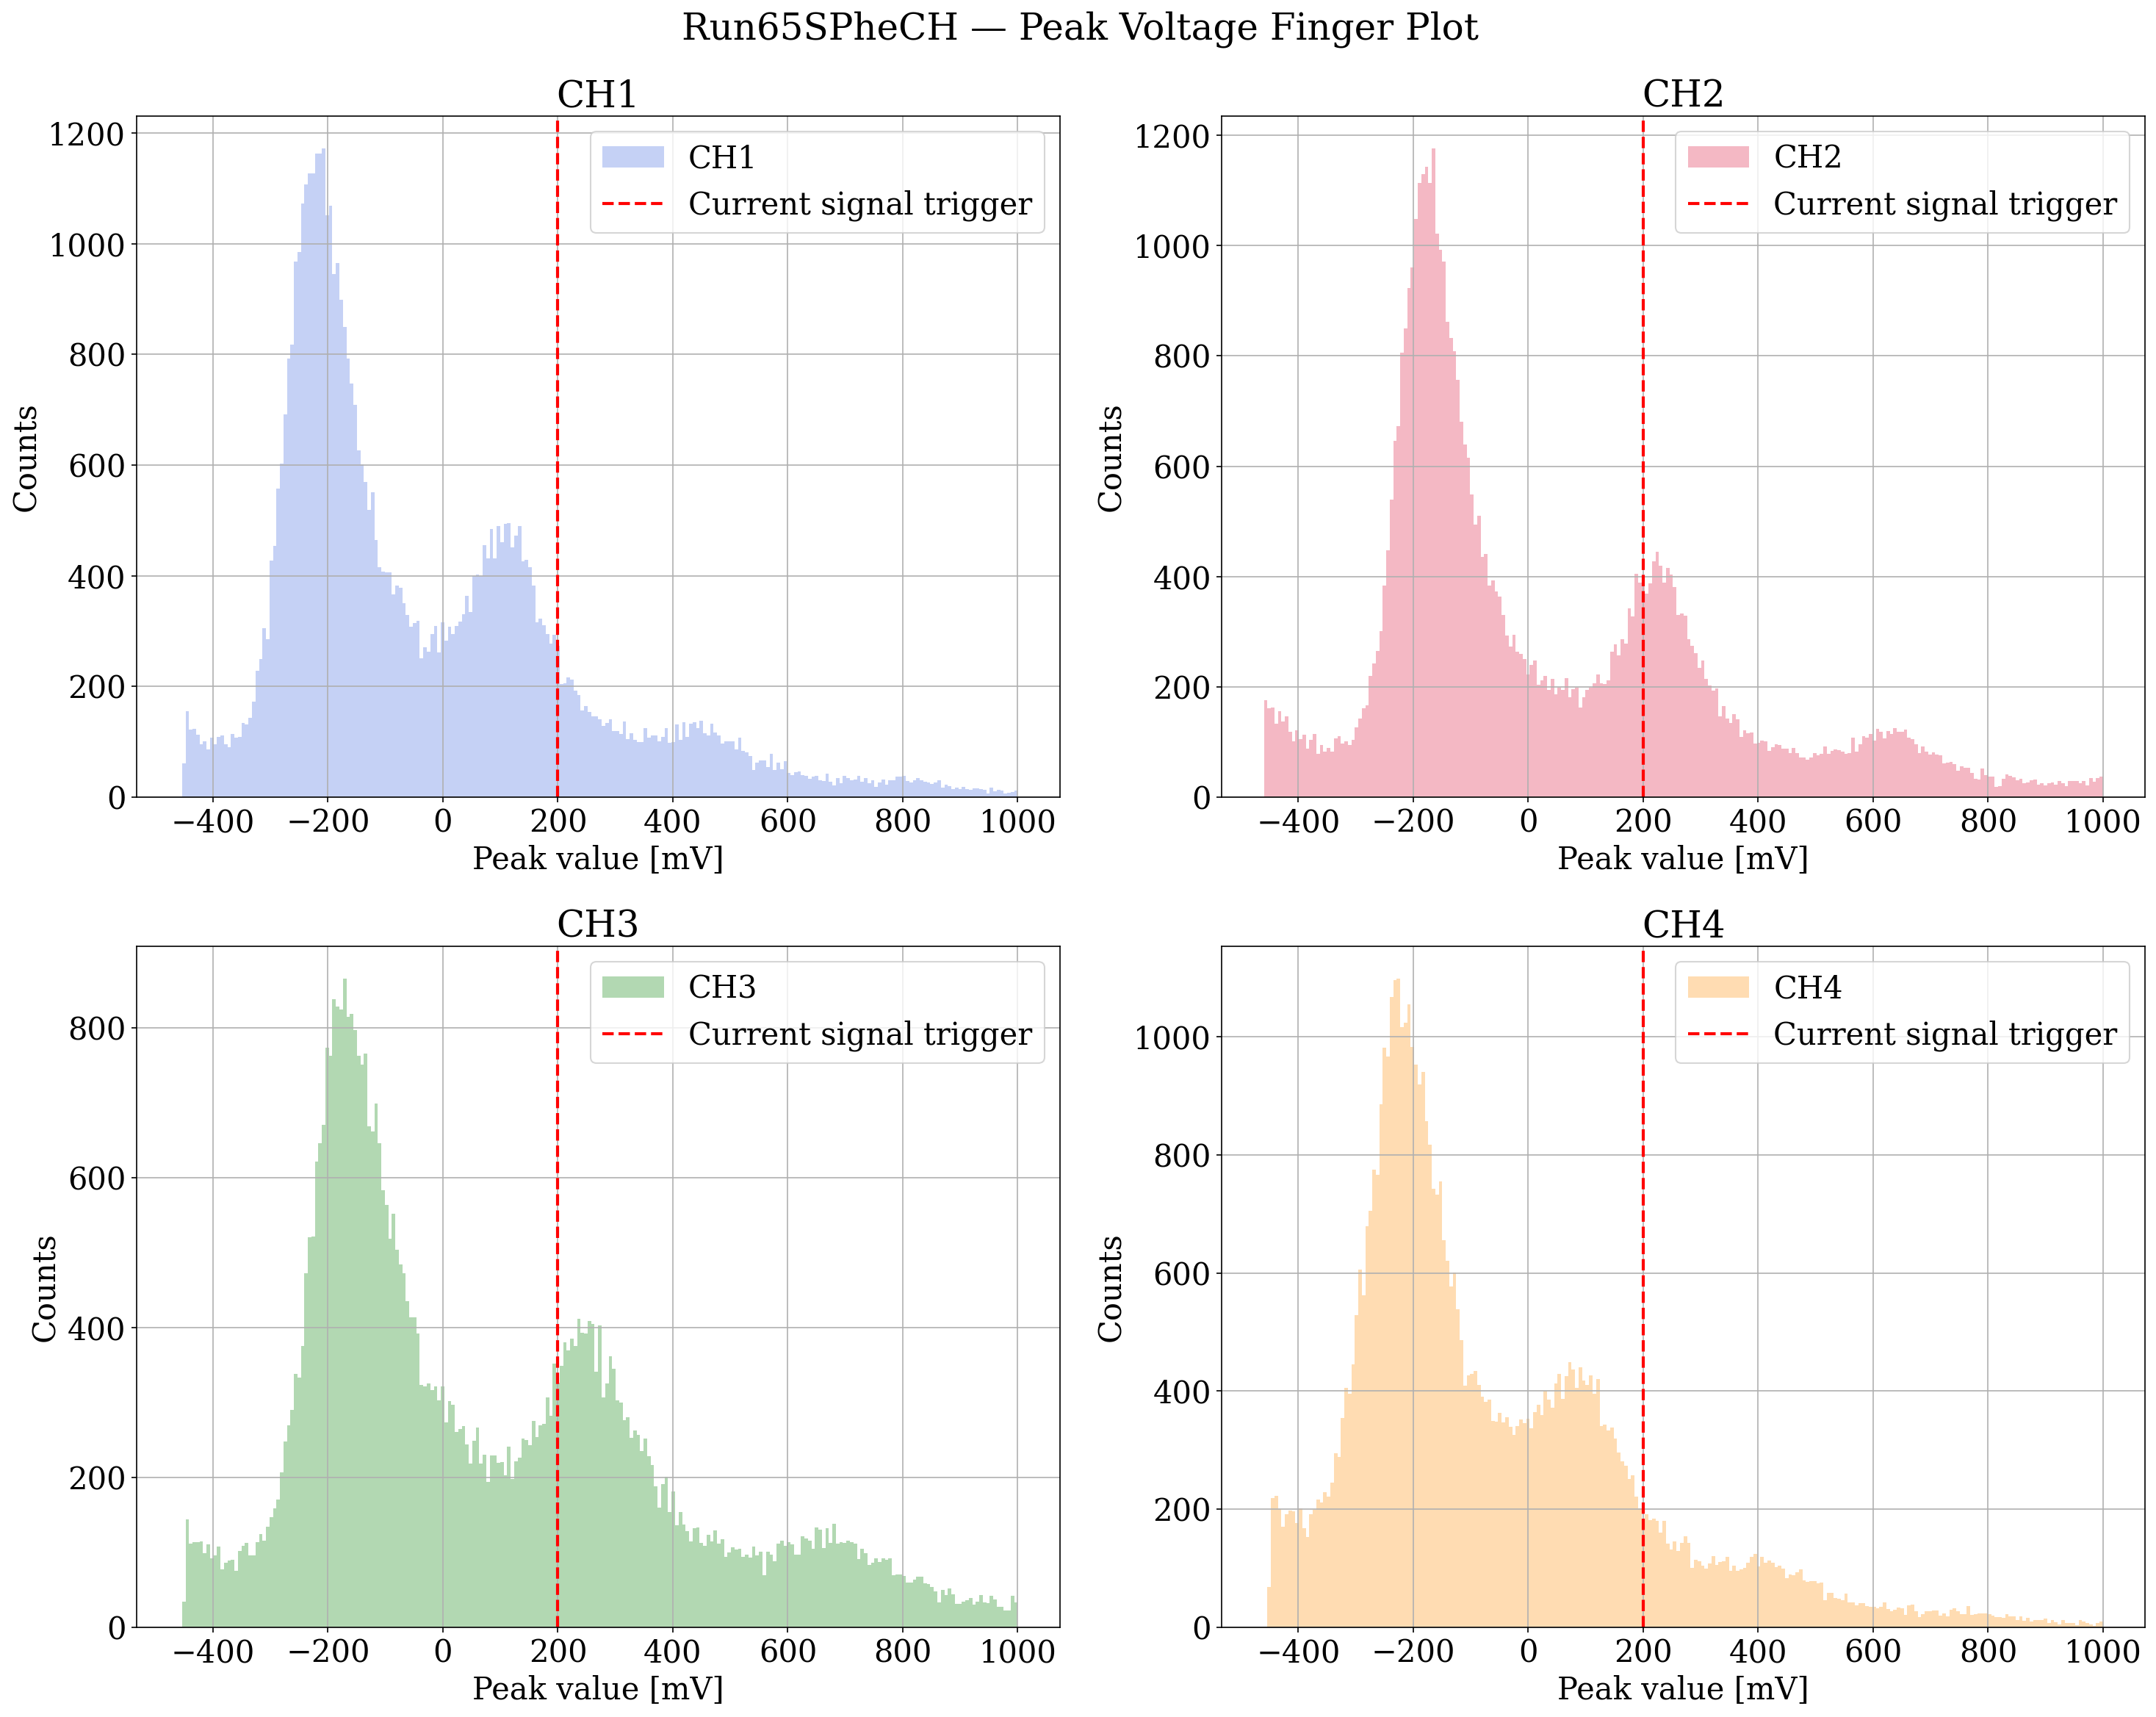

In [ ]:
n_gaussians = 2
voltage_opt_A, voltage_opt_mu, voltage_opt_sigma, voltage_opt_mu_errors = FingerPlotVoltage(filtered_df, channels, n_gaussians)